# Uygulamalı Makine Öğrenmesi
## Hafta 2 — Lojistik Regresyon (Logistic Regression)

---

> **Ders Notu Bilgileri**  
> - **Düzey:** Lisans 3-4. Sınıf & Yüksek Lisans  
> - **Süre:** ~3 ders saati  
> - **Önkoşul:** Python, NumPy, Pandas, EDA, KNN bilgisi  
> - **Kütüphaneler:** NumPy · Pandas · Scikit-learn · Plotly · Seaborn · Altair  

---

## İçindekiler

| # | Konu | Tür |
|---|------|-----|
| 1 | Kütüphane Kurulumu | Kod |
| 2 | Lojistik Regresyon Nedir? | Teori |
| 3 | Lineer Regresyondan Farkı | Teori |
| 4 | Sigmoid Fonksiyonu | Teori + Kod |
| 5 | Karar Sınırı (Decision Boundary) | Teori + Kod |
| 6 | Maliyet Fonksiyonu: Binary Cross-Entropy | Teori + Kod |
| 7 | Gradyan İniş (Gradient Descent) | Teori + Kod |
| 8 | Veri Setleri ve Kaynaklar | Bilgi |
| 9 | EDA: Breast Cancer Veri Seti | Kod |
| 10 | Veri Ön İşleme | Kod |
| 11 | Sıfırdan Lojistik Regresyon (NumPy) | Kod |
| 12 | Scikit-learn ile Lojistik Regresyon | Kod |
| 13 | Model Değerlendirme: Confusion Matrix, F1, AUC | Kod |
| 14 | ROC Eğrisi ve AUC | Kod |
| 15 | Katsayı Yorumlama (Odds Ratio) | Kod |
| 16 | Regularization: L1 (Lasso) ve L2 (Ridge) | Kod |
| 17 | Çok Sınıflı Lojistik Regresyon | Kod |
| 18 | KNN ile Karşılaştırma | Kod |
| 19 | Gerçek Dünya: Titanic | Kod |
| 20 | Özet ve Sonraki Adımlar | Özet |

---
## 1. Kütüphane Kurulumu & İçe Aktarma

In [1]:
# ─── Temel Bilimsel Hesaplama ───────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Görselleştirme ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import altair as alt

# ─── Scikit-learn: Veri Setleri ─────────────────────────────────────────────
from sklearn.datasets import load_breast_cancer, load_iris, make_classification

# ─── Scikit-learn: Ön İşleme ────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler

# ─── Scikit-learn: Modeller ─────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

# ─── Scikit-learn: Metrikler ────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve, f1_score
)

# ─── Diğer ──────────────────────────────────────────────────────────────────
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ─── Görsel Ayarlar ─────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='husl', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Tüm kütüphaneler yüklendi!')

Tüm kütüphaneler yüklendi!


---
## 2. Lojistik Regresyon Nedir?

### Tanım

Lojistik Regresyon, adındaki "regresyon" kelimesine rağmen bir **sınıflandırma** algoritmasıdır. Bir gözlemin belirli bir sınıfa ait olma **olasılığını** tahmin eder.

$$P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}$$

### Temel Özellikler

| Özellik | Açıklama |
|---------|----------|
| **Tür** | Denetimli Öğrenme (Supervised) |
| **Görev** | Sınıflandırma (İkili & Çok Sınıflı) |
| **Çıktı** | Olasılık değeri ∈ [0, 1] |
| **Parametrik mi?** | Evet — w ve b parametrelerini öğrenir |
| **Karar Sınırı** | Doğrusal |
| **Temel Fonksiyon** | Sigmoid (Logistic) fonksiyonu |

### Neden "Regresyon" Adı Taşıyor?

Sigmoid fonksiyonu uygulanmadan önce model, **lineer bir regresyon** hesaplar:

$$z = \mathbf{w}^T \mathbf{x} + b = w_1 x_1 + w_2 x_2 + \ldots + w_d x_d + b$$

Bu $z$ değeri (log-odds / logit) sigmoid fonksiyonuna girilerek olasılığa dönüştürülür.

---
## 3. Lineer Regresyondan Farkı

| Özellik | Lineer Regresyon | Lojistik Regresyon |
|---------|------------------|--------------------|
| **Amaç** | Sürekli değer tahmini | Sınıf olasılığı tahmini |
| **Çıktı aralığı** | (−∞, +∞) | [0, 1] |
| **Aktivasyon** | Yok (kimlik) | Sigmoid |
| **Maliyet fon.** | MSE (kare hata) | Binary Cross-Entropy |
| **Değerlendirme** | RMSE, R² | Accuracy, F1, AUC |
| **Varsayım** | Doğrusal ilişki | Doğrusal karar sınırı |

### Temel Problem: Neden Lineer Regresyon Sınıflandırmada Kullanılmaz?

- Lineer modelin çıktısı [0,1] aralığında kalmaz → olasılık yorumu imkânsız
- Aykırı değerler karar sınırını bozar
- MSE, sınıflandırma için uygun bir kayıp fonksiyonu değildir

---
## 4. Sigmoid Fonksiyonu

Sigmoid (lojistik) fonksiyonu, herhangi bir gerçek sayıyı (−∞, +∞) → (0, 1) aralığına sıkıştırır:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

### Kritik Özellikler:

- $\sigma(0) = 0.5$ → karar eşiği
- $z \to +\infty \Rightarrow \sigma(z) \to 1$
- $z \to -\infty \Rightarrow \sigma(z) \to 0$
- Türevi: $\sigma'(z) = \sigma(z)(1 - \sigma(z))$ → gradyan hesabında kritik!

### Yorumlama:

$$\hat{y} = \begin{cases} 1 & \text{if } \sigma(z) \geq 0.5 \\ 0 & \text{if } \sigma(z) < 0.5 \end{cases}$$

In [2]:
# ─── Sigmoid Fonksiyonu — Hesaplama ve Görselleştirme ───────────────────────

# z değerleri: -10'dan +10'a kadar 500 nokta
z = np.linspace(-10, 10, 500)

# Sigmoid hesabı: σ(z) = 1 / (1 + e^(-z))
sigmoid = 1 / (1 + np.exp(-z))

# Sigmoid türevi: σ'(z) = σ(z) * (1 - σ(z))
sigmoid_deriv = sigmoid * (1 - sigmoid)

# ─── Plotly ile İnteraktif Grafik ───────────────────────────────────────────
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Sigmoid Fonksiyonu σ(z)', 'Sigmoid Türevi σ\'(z)')
)

# Sol: Sigmoid eğrisi
fig.add_trace(go.Scatter(
    x=z, y=sigmoid,
    mode='lines', line=dict(color='#2196F3', width=3),
    name='σ(z)'
), row=1, col=1)

# z=0 noktasını işaretle
fig.add_trace(go.Scatter(
    x=[0], y=[0.5],
    mode='markers+text',
    marker=dict(size=12, color='red', symbol='circle'),
    text=['σ(0) = 0.5'], textposition='top right',
    showlegend=False
), row=1, col=1)

# Karar eşiği yatay çizgisi
fig.add_hline(y=0.5, line_dash='dash', line_color='red',
              annotation_text='Karar Eşiği (0.5)', row=1, col=1)

# Sağ: Türev eğrisi
fig.add_trace(go.Scatter(
    x=z, y=sigmoid_deriv,
    mode='lines', line=dict(color='#FF9800', width=3),
    name="σ'(z)"
), row=1, col=2)

# z=0'da maksimum türev
fig.add_trace(go.Scatter(
    x=[0], y=[0.25],
    mode='markers+text',
    marker=dict(size=12, color='green', symbol='circle'),
    text=["σ'(0) = 0.25"], textposition='top right',
    showlegend=False
), row=1, col=2)

fig.update_layout(
    height=400,
    title_text='Sigmoid Fonksiyonu ve Türevi',
    template='plotly_white',
    showlegend=True
)
fig.update_xaxes(title_text='z (log-odds)')
fig.update_yaxes(title_text='σ(z)', row=1, col=1)
fig.update_yaxes(title_text="σ'(z)", row=1, col=2)

fig.show()

print('Türev z=0 noktasında maksimum (0.25). Bu, öğrenmenin en hızlı karar sınırı yakınında olduğunu gösterir.')

Türev z=0 noktasında maksimum (0.25). Bu, öğrenmenin en hızlı karar sınırı yakınında olduğunu gösterir.


### Sol Grafik — Sigmoid Fonksiyonu σ(z)

Sigmoid, herhangi bir sayıyı **0 ile 1 arasına sıkıştıran** bir matematiksel fonksiyondur.

- Girdi (z ekseni) çok küçükse → çıktı **0'a** yaklaşır
- Girdi çok büyükse → çıktı **1'e** yaklaşır
- Girdi tam **0** olduğunda → çıktı tam **0.5** olur (kırmızı nokta)

> Pratikte bu, bir olayın **olasılığını** tahmin etmek için kullanılır. Örneğin: "Bu e-posta spam mı?" → %70 ihtimal = 0.70

---

### Sağ Grafik — Türev σ'(z)

Türev, fonksiyonun **ne kadar hızlı değiştiğini** gösterir.

- Eğri **z = 0** noktasında tepe yapar → maksimum değişim hızı **0.25**
- Uçlara gidildikçe (çok büyük ya da çok küçük z) eğri **düzleşir** → fonksiyon artık değişmiyor

> Yani model en çok, kararsız olduğu durumlarda (ortada) öğrenir; emin olduğu durumlarda ise öğrenme yavaşlar.

---

**Özet:** Sol grafik "karar ver", sağ grafik "ne kadar öğreniyorsun" sorusunu yanıtlar.

In [3]:
# ─── Sigmoid'in Farklı z Değerlerindeki Çıktıları ───────────────────────────
# Bu hücre sigmoid davranışını sayısal olarak gösterir

z_vals   = [-10, -5, -2, -1, 0, 1, 2, 5, 10]
sig_vals = [1 / (1 + np.exp(-z)) for z in z_vals]

df_sig = pd.DataFrame({
    'z (log-odds)': z_vals,
    'σ(z) = P(y=1)': [round(s, 4) for s in sig_vals],
    'Tahmin (threshold=0.5)': ['Sınıf 1' if s >= 0.5 else 'Sınıf 0' for s in sig_vals]
})

print('Sigmoid Değerleri:')
print(df_sig.to_string(index=False))
print()
print('z = 0 → olasılık tam olarak 0.5 (eşit belirsizlik)')
print('z = 5  → olasılık = 0.9933 (neredeyse kesin Sınıf 1)')
print('z = -5 → olasılık = 0.0067 (neredeyse kesin Sınıf 0)')

Sigmoid Değerleri:
 z (log-odds)  σ(z) = P(y=1) Tahmin (threshold=0.5)
          -10         0.0000                Sınıf 0
           -5         0.0067                Sınıf 0
           -2         0.1192                Sınıf 0
           -1         0.2689                Sınıf 0
            0         0.5000                Sınıf 1
            1         0.7311                Sınıf 1
            2         0.8808                Sınıf 1
            5         0.9933                Sınıf 1
           10         1.0000                Sınıf 1

z = 0 → olasılık tam olarak 0.5 (eşit belirsizlik)
z = 5  → olasılık = 0.9933 (neredeyse kesin Sınıf 1)
z = -5 → olasılık = 0.0067 (neredeyse kesin Sınıf 0)


---
## 5. Karar Sınırı (Decision Boundary)

Lojistik Regresyon **doğrusal** bir karar sınırı oluşturur.

Sınır, $\sigma(z) = 0.5$ olduğu yerde, yani $z = 0$ noktasındadır:

$$\mathbf{w}^T \mathbf{x} + b = 0 \quad \Rightarrow \quad w_1 x_1 + w_2 x_2 + b = 0$$

Bu denklem 2D'de bir **doğru** (line), 3D'de bir **düzlem** (plane), yüksek boyutlarda ise bir **hiper düzlem** (hyperplane) tanımlar.

### Kısıt:
Lojistik Regresyon yalnızca **doğrusal ayrılabilir** (linearly separable) problemlerde başarılı olur.  
Doğrusal olmayan sınırlar için: Kernel SVM, Karar Ağaçları, Sinir Ağları tercih edilmelidir.

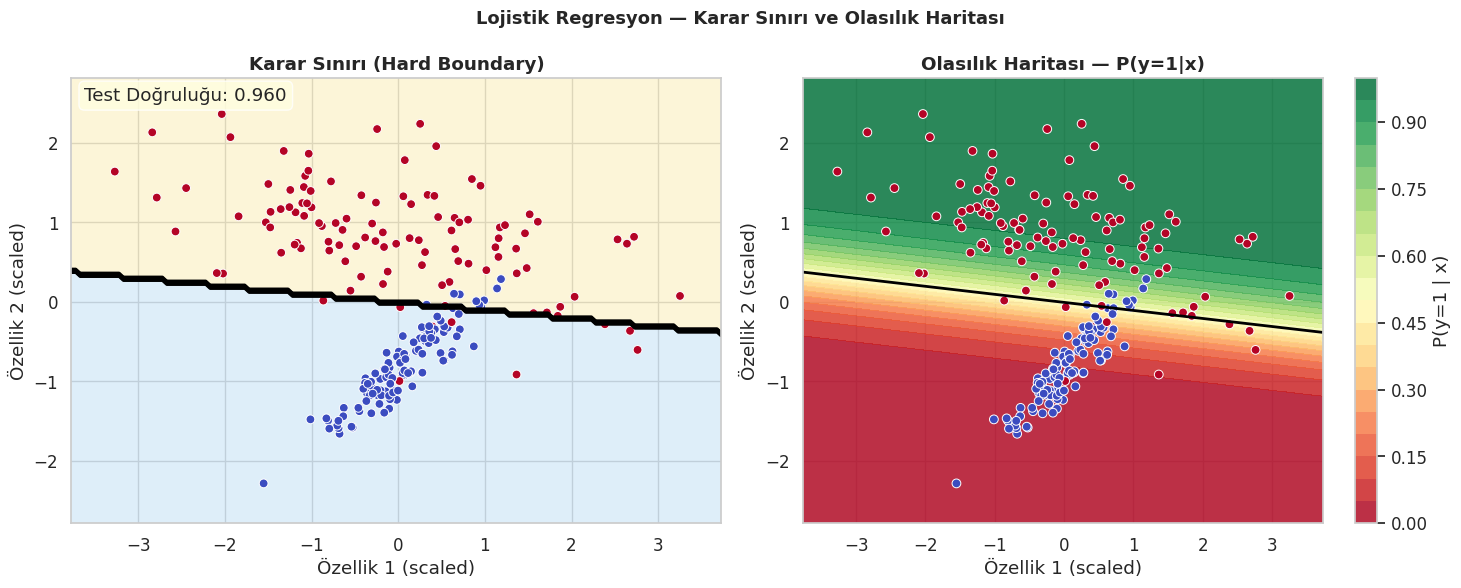


 Doğruluk: 0.9600
   Katsayılar  w = [0.371 3.669]
   Bias        b = 0.021


In [4]:
# ─── Karar Sınırı Görselleştirmesi ──────────────────────────────────────────
# 2D sentetik veri üzerinde lojistik regresyonun karar sınırını çiziyoruz

from sklearn.datasets import make_classification
import matplotlib.colors as mcolors

# 2 özellikli, 2 sınıflı sentetik veri üret
X_synth, y_synth = make_classification(
    n_samples=300, n_features=2, n_redundant=0,
    n_informative=2, random_state=RANDOM_STATE, n_clusters_per_class=1
)

# Modeli eğit
X_s_train, X_s_test, y_s_train, y_s_test = train_test_split(
    X_synth, y_synth, test_size=0.25, random_state=RANDOM_STATE
)

scaler_synth = StandardScaler()
X_s_tr_sc = scaler_synth.fit_transform(X_s_train)
X_s_te_sc = scaler_synth.transform(X_s_test)

# Lojistik Regresyon eğit
lr_synth = LogisticRegression(random_state=RANDOM_STATE)
lr_synth.fit(X_s_tr_sc, y_s_train)

# Karar bölgeleri için ızgara oluştur
h = 0.05
x_min, x_max = X_s_tr_sc[:, 0].min() - 0.5, X_s_tr_sc[:, 0].max() + 0.5
y_min, y_max = X_s_tr_sc[:, 1].min() - 0.5, X_s_tr_sc[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Her ızgara noktası için sınıf ve olasılık tahmin et
Z_class = lr_synth.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
Z_prob  = lr_synth.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Sol: Sert karar sınırı
ax = axes[0]
ax.contourf(xx, yy, Z_class, alpha=0.4,
            cmap=mcolors.ListedColormap(['#AED6F1', '#F9E79F']))
ax.contour(xx, yy, Z_class, colors='black', linewidths=2)
scatter = ax.scatter(X_s_tr_sc[:, 0], X_s_tr_sc[:, 1],
                     c=y_s_train, cmap='coolwarm', edgecolors='w',
                     s=40, linewidth=0.7)
ax.set_title('Karar Sınırı (Hard Boundary)', fontweight='bold')
ax.set_xlabel('Özellik 1 (scaled)')
ax.set_ylabel('Özellik 2 (scaled)')
acc = lr_synth.score(X_s_te_sc, y_s_test)
ax.text(0.02, 0.98, f'Test Doğruluğu: {acc:.3f}',
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Sağ: Olasılık haritası
ax = axes[1]
cf = ax.contourf(xx, yy, Z_prob, levels=20, cmap='RdYlGn', alpha=0.85)
plt.colorbar(cf, ax=ax, label='P(y=1 | x)')
ax.scatter(X_s_tr_sc[:, 0], X_s_tr_sc[:, 1],
           c=y_s_train, cmap='coolwarm', edgecolors='w',
           s=40, linewidth=0.7)
ax.contour(xx, yy, Z_prob, levels=[0.5], colors='black', linewidths=2)
ax.set_title('Olasılık Haritası — P(y=1|x)', fontweight='bold')
ax.set_xlabel('Özellik 1 (scaled)')
ax.set_ylabel('Özellik 2 (scaled)')

plt.suptitle('Lojistik Regresyon — Karar Sınırı ve Olasılık Haritası',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n Doğruluk: {acc:.4f}')
print(f'   Katsayılar  w = {lr_synth.coef_[0].round(3)}')
print(f'   Bias        b = {lr_synth.intercept_[0]:.3f}')

## Görsel: Lojistik Regresyon — Karar Sınırı ve Olasılık Haritası

Bu görsel, bir **sınıflandırma modelinin** iki farklı bakış açısıyla anlatımıdır. Model, kırmızı ve mavi noktaları birbirinden ayırt etmeye çalışıyor.

### Sol Grafik — Karar Sınırı

Model, ortadaki **kalın siyah çizgiyle** iki bölge oluşturuyor:

- Çizginin **üstü → sarı alan** = "Bu kırmızı nokta" kararı
- Çizginin **altı → mavi alan** = "Bu mavi nokta" kararı

Model ya **evet** ya **hayır** diyor; arada kalmıyor. Buna "hard boundary" (sert sınır) denir.

> **Test Doğruluğu: 0.96** → Model, test verilerinin %96'sını doğru sınıflandırmış. Oldukça başarılı!

---

### Sağ Grafik — Olasılık Haritası

Sol grafiğin "içini" gösterir. Model aslında keskin karar vermeden önce bir **olasılık hesaplar:**

- 🟢 **Koyu yeşil** → "Kesinlikle kırmızı" (%90+)
- 🔴 **Koyu kırmızı** → "Kesinlikle mavi" (%0'a yakın)
- 🟡 **Ortadaki soluk renkler** → Model kararsız, yaklaşık %50-50

Siyah çizgi tam olarak **%50 olasılık sınırı** — buradan geçince karar değişiyor.

---

**Özet:** Model iki grubu birbirinden ayıran bir çizgi çiziyor. Sol grafik son kararı, sağ grafik ise o kararın ne kadar emin verdiğini gösteriyor. %96 doğrulukla oldukça iyi iş çıkarmış!

---
## 6. Maliyet Fonksiyonu: Binary Cross-Entropy

Lojistik regresyon **MSE yerine** Binary Cross-Entropy (Log Loss) kullanır.

**Neden MSE Kullanılmaz?**  
MSE, sigmoid çıktısıyla birleştiğinde **konveks olmayan** bir maliyet yüzeyi oluşturur — birden fazla lokal minimum vardır.

### Binary Cross-Entropy (Log Loss):

$$\mathcal{L}(\mathbf{w}) = -\frac{1}{N} \sum_{i=1}^{N} \left[ y^{(i)} \log(\hat{p}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{p}^{(i)}) \right]$$

Burada $\hat{p}^{(i)} = \sigma(\mathbf{w}^T \mathbf{x}^{(i)} + b)$

**İki terim şöyle çalışır:**
- $y=1$ ise: $-\log(\hat{p})$ → $\hat{p} \to 1$ olduğunda kayıp → 0
- $y=0$ ise: $-\log(1-\hat{p})$ → $\hat{p} \to 0$ olduğunda kayıp → 0

Bu fonksiyon **konveks** (convex) olduğundan global minimum garantilidir!

In [5]:
# ─── Cross-Entropy Kayıp Fonksiyonu Görselleştirmesi ────────────────────────
# y=1 ve y=0 durumlarında kayıp nasıl değişiyor?

# Tahmin olasılığı: 0.001'den 0.999'a (0 ve 1 log için dışarıda)
p_hat = np.linspace(0.001, 0.999, 500)

# y=1 durumu için kayıp: -log(p̂)
loss_y1 = -np.log(p_hat)

# y=0 durumu için kayıp: -log(1-p̂)
loss_y0 = -np.log(1 - p_hat)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=p_hat, y=loss_y1,
    mode='lines', line=dict(color='#E74C3C', width=3),
    name='y=1 kaybı: −log(p̂)'
))

fig.add_trace(go.Scatter(
    x=p_hat, y=loss_y0,
    mode='lines', line=dict(color='#3498DB', width=3),
    name='y=0 kaybı: −log(1−p̂)'
))

# Ceza noktalarını işaretle
fig.add_trace(go.Scatter(
    x=[0.1], y=[-np.log(0.1)],
    mode='markers+text',
    marker=dict(size=12, color='red'),
    text=['Yüksek ceza!<br>(y=1 ama p̂=0.1)'],
    textposition='top right',
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=[0.9], y=[-np.log(1-0.9)],
    mode='markers+text',
    marker=dict(size=12, color='blue'),
    text=['Yüksek ceza!<br>(y=0 ama p̂=0.9)'],
    textposition='top left',
    showlegend=False
))

fig.update_layout(
    title='Binary Cross-Entropy — Kayıp Fonksiyonu',
    xaxis_title='Tahmin Olasılığı p̂',
    yaxis_title='Kayıp (Loss)',
    yaxis_range=[0, 5],
    height=430,
    template='plotly_white'
)

fig.show()

print('Eğer gerçek etiket 1 ama model 0 tahmin ederse → ceza çok yüksek!')
print('Güvenli tahminlere (p̂ ≈ 1 veya p̂ ≈ 0) düşük ceza verilir.')

Eğer gerçek etiket 1 ama model 0 tahmin ederse → ceza çok yüksek!
Güvenli tahminlere (p̂ ≈ 1 veya p̂ ≈ 0) düşük ceza verilir.


## Görsel: Binary Cross-Entropy — Kayıp Fonksiyonu

Bu grafik, modelin **ne kadar yanıldığını ölçen** bir ceza sistemini gösteriyor.

### Temel Fikir

Model her tahmin için bir olasılık üretir (0 ile 1 arası). Gerçek cevapla karşılaştırılınca bir **ceza puanı (kayıp)** hesaplanır. Bu grafik o cezanın nasıl değiştiğini gösteriyor.

---

### 🔴 Kırmızı Eğri — Gerçek cevap "1" (Evet) iken

- Model **0.1 tahmin ederse** → ceza **çok yüksek** (kırmızı nokta, sol üst)
- Model **0.9 tahmin ederse** → ceza **neredeyse sıfır**

> Yani gerçek cevap "evet"ken model "hayır" diyorsa ağır ceza yiyor.

---

### 🔵 Mavi Eğri — Gerçek cevap "0" (Hayır) iken

- Model **0.9 tahmin ederse** → ceza **çok yüksek** (mavi nokta, sağ üst)
- Model **0.1 tahmin ederse** → ceza **neredeyse sıfır**

> Tam tersi: gerçek cevap "hayır"ken model "evet" diyorsa ağır ceza yiyor.

---

### Özet

| Durum | Ceza |
|---|---|
| Doğru ve emin tahmin | Düşük |
| Yanlış ve emin tahmin | Çok yüksek |
| Kararsız tahmin (~0.5) | Orta |

Model bu cezayı minimize etmeye çalışarak öğrenir. **Yanlış ve özgüvenli olmak** en kötü senaryodur

---
## 7. Gradyan İniş (Gradient Descent)

Kayıp fonksiyonunu minimize etmek için **gradyan iniş** kullanılır.

### Güncelleme Kuralı:

$$\mathbf{w} \leftarrow \mathbf{w} - \eta \cdot \nabla_\mathbf{w} \mathcal{L}$$
$$b \leftarrow b - \eta \cdot \frac{\partial \mathcal{L}}{\partial b}$$

Burada $\eta$ (eta) **öğrenme hızı** (learning rate) hiperparametresidir.

### Gradyanların Kapalı Formu:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \frac{1}{N} \mathbf{X}^T (\hat{\mathbf{p}} - \mathbf{y})$$

$$\frac{\partial \mathcal{L}}{\partial b} = \frac{1}{N} \sum_{i=1}^{N} (\hat{p}^{(i)} - y^{(i)})$$

**Not:** Bu gradyanlar, türev zinciri kuralıyla sigmoid ve cross-entropy'nin birleşiminden elde edilir. Matematiksel olarak **son derece temiz** bir forma sahiptir!

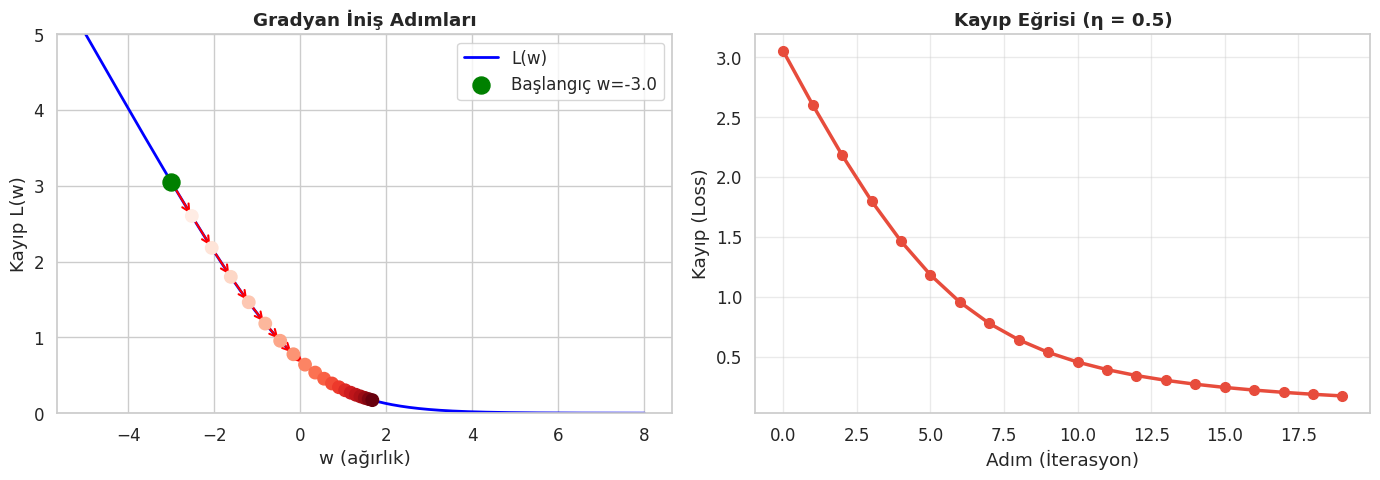

Son w değeri: 1.6736  →  Optimal w büyük pozitif sayı
Son kayıp:    0.171911


In [6]:
# ─── Gradyan İnişin Görselleştirilmesi (Kayıp eğrisi üzerinde) ───────────────
# Tek bir ağırlık (w) için kayıp fonksiyonunun evrimini gösteriyoruz

# Basit bir 1D örnek: X = [1], y = [1], b = 0 sabit
# Kayıp: L(w) = -log(σ(w)) (y=1 için)
w_range = np.linspace(-5, 8, 400)
loss_vals = -np.log(1 / (1 + np.exp(-w_range)))   # y=1 için cross-entropy

# Gradyan iniş simülasyonu
eta = 0.5      # öğrenme hızı
w_curr = -3.0  # başlangıç değeri
w_history = [w_curr]
loss_history = []

for step in range(20):
    # ileri geçiş: sigmoid hesapla
    p_hat_curr = 1 / (1 + np.exp(-w_curr))
    # kayıp hesapla
    loss_curr = -np.log(p_hat_curr + 1e-9)
    loss_history.append(loss_curr)
    # gradyan: ∂L/∂w = p̂ - y = p̂ - 1 (y=1)
    grad = p_hat_curr - 1
    # güncelle
    w_curr = w_curr - eta * grad
    w_history.append(w_curr)

w_history_arr  = np.array(w_history[:-1])
loss_history_arr = np.array(loss_history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: Kayıp yüzeyi üzerinde adımlar
ax = axes[0]
ax.plot(w_range, loss_vals, 'b-', linewidth=2, label='L(w)')
ax.scatter(w_history_arr, loss_history_arr,
           c=range(len(w_history_arr)), cmap='Reds', s=80, zorder=5)
# Adımları okla göster
for i in range(min(10, len(w_history_arr)-1)):
    ax.annotate('', xy=(w_history_arr[i+1], loss_history_arr[i+1]),
                xytext=(w_history_arr[i], loss_history_arr[i]),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
ax.scatter(w_history_arr[0], loss_history_arr[0],
           c='green', s=150, zorder=6, label=f'Başlangıç w={w_history_arr[0]:.1f}')
ax.set_xlabel('w (ağırlık)')
ax.set_ylabel('Kayıp L(w)')
ax.set_title('Gradyan İniş Adımları', fontweight='bold')
ax.legend()
ax.set_ylim(0, 5)

# Sağ: Kayıp vs adım
ax = axes[1]
ax.plot(range(len(loss_history_arr)), loss_history_arr,
        'o-', color='#E74C3C', linewidth=2.5, markersize=7)
ax.set_xlabel('Adım (İterasyon)')
ax.set_ylabel('Kayıp (Loss)')
ax.set_title(f'Kayıp Eğrisi (η = {eta})', fontweight='bold')
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print(f'Son w değeri: {w_history_arr[-1]:.4f}  →  Optimal w büyük pozitif sayı')
print(f'Son kayıp:    {loss_history_arr[-1]:.6f}')

## Görsel: Gradyan İniş Adımları

Bu görsel, modelin **kendi kendini nasıl düzelttiğini** adım adım gösteriyor.

### Temel Fikir

Model başta hatalı tahminler yapıyor. Gradyan iniş, modelin hatayı azaltmak için ağırlığını (w) yavaş yavaş ayarladığı bir öğrenme yöntemidir. Bunu bir **tepeyi aşağı inen top** gibi düşünebilirsiniz.

---

### Sol Grafik — İniş Adımları

- 🟢 **Yeşil nokta**: Başlangıç noktası, w = -3.0, kayıp ≈ 3.05 (çok hatalı)
- Kırmızı oklar her adımda modelin **eğrinin aşağısına doğru kaydığını** gösteriyor
- 🔴 **Koyu kırmızı nokta**: Durduğu yer, w ≈ 1.67, kayıp ≈ 0.17 (çok az hata)

> Model tepeden başlayıp vadiye iniyor — kayıp minimuma ulaşıyor.

---

### Sağ Grafik — Kayıp Eğrisi

Her adımda kaybın nasıl düştüğünü gösteriyor:

- **İlk adımlarda** kayıp hızla düşüyor (eğim dik)
- **İlerleyen adımlarda** düşüş yavaşlıyor (düzlüğe ulaşılıyor)
- 20 adım sonunda kayıp **0.17'ye** iniyor

---

### Özet

| | Başlangıç | Bitiş |
|---|---|---|
| Ağırlık (w) | -3.0 | +1.67 |
| Kayıp | ~3.05 | ~0.17 |

Model 20 adımda hatasını **18 kat azaltmış!** Öğrenme hızı (η = 0.5) ne çok büyük ne çok küçük seçilmiş — bu yüzden iniş düzgün gerçekleşmiş.

---
## 8. Kullanılan Veri Setleri ve Kaynaklar

### Veri Seti 1: Breast Cancer Wisconsin

| Bilgi | Detay |
|-------|-------|
| **Kaynak** | W.H. Wolberg et al., UCI ML Repository (1992) |
| **URL** | https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic) |
| **Scikit-learn** | `sklearn.datasets.load_breast_cancer()` |
| **Örnek Sayısı** | 569 (357 benign, 212 malignant) |
| **Özellik Sayısı** | 30 (hücre çekirdeği ölçümleri) |
| **Sınıf Sayısı** | 2 (benign=0, malignant=1) |
| **Kullanım Amacı** | Temel lojistik regresyon, ROC analizi |

### Veri Seti 2: Iris (Çok Sınıflı)

| Bilgi | Detay |
|-------|-------|
| **Kaynak** | R.A. Fisher (1936), UCI ML Repository |
| **Scikit-learn** | `sklearn.datasets.load_iris()` |
| **Kullanım Amacı** | Çok sınıflı lojistik regresyon (Softmax) |

### Veri Seti 3: Titanic

| Bilgi | Detay |
|-------|-------|
| **Kaynak** | Kaggle — https://www.kaggle.com/c/titanic |
| **Kullanım Amacı** | Gerçek dünya, feature engineering, yorumlama |

In [7]:
# ─── Breast Cancer Veri Setini Yükle ────────────────────────────────────────
cancer = load_breast_cancer()

# Pandas DataFrame'e çevir
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

# Hedef sütunu ekle (0=malignant, 1=benign — sklearn'de böyle tanımlı)
df['target'] = cancer.target
df['diagnosis'] = df['target'].map({0: 'Malignant (Kötü Huylu)',
                                     1: 'Benign (İyi Huylu)'})

print('=== BREAST CANCER VERİ SETİ ===')
print(f'Kaynak  : UCI ML Repository (W.H. Wolberg, 1992)')
print(f'Boyut   : {df.shape[0]} satır × {cancer.data.shape[1]} özellik')
print(f'Eksik   : {df.isnull().sum().sum()} değer')
print(f'Sınıflar: {dict(Counter(df["diagnosis"]))}')
print()
df.head()

=== BREAST CANCER VERİ SETİ ===
Kaynak  : UCI ML Repository (W.H. Wolberg, 1992)
Boyut   : 569 satır × 30 özellik
Eksik   : 0 değer
Sınıflar: {'Malignant (Kötü Huylu)': 212, 'Benign (İyi Huylu)': 357}



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant (Kötü Huylu)
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant (Kötü Huylu)
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant (Kötü Huylu)
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant (Kötü Huylu)
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant (Kötü Huylu)


---
## 9. EDA: Breast Cancer Veri Seti

In [8]:
# ─── Temel İstatistikler — Sınıflara Göre Karşılaştırma ─────────────────────
# Her iki sınıfın özellik ortalamalarını karşılaştır

key_features = ['mean radius', 'mean texture', 'mean perimeter',
                'mean area', 'mean smoothness', 'mean concavity']

stats_by_class = df.groupby('diagnosis')[key_features].agg(['mean', 'std']).round(3)

print('Sınıflara Göre Temel Özellik İstatistikleri:')
display(stats_by_class)

Sınıflara Göre Temel Özellik İstatistikleri:


mean radius        mean texture        mean perimeter  \
                              mean    std         mean    std           mean   
diagnosis                                                                      
Benign (İyi Huylu)          12.147  1.781       17.915  3.995         78.075   
Malignant (Kötü Huylu)      17.463  3.204       21.605  3.779        115.365   

                               mean area          mean smoothness         \
                           std      mean      std            mean    std   
diagnosis                                                                  
Benign (İyi Huylu)      11.807   462.790  134.287           0.092  0.013   
Malignant (Kötü Huylu)  21.855   978.376  367.938           0.103  0.013   

                       mean concavity         
                                 mean    std  
diagnosis                                     
Benign (İyi Huylu)              0.046  0.043  
Malignant (Kötü Huylu)          0.161  0.075

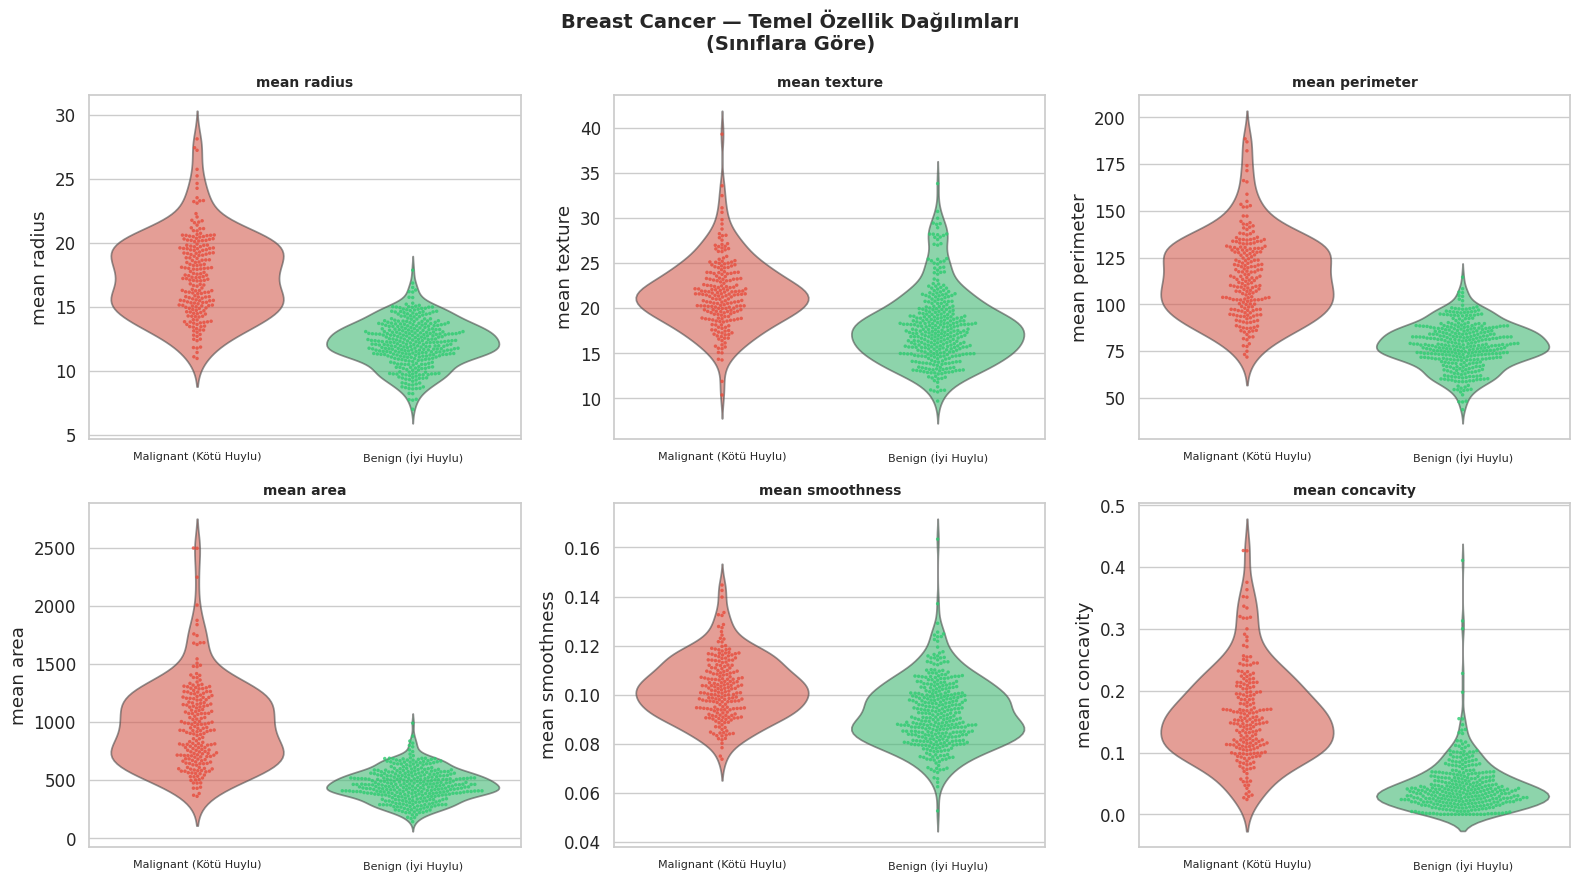

Malignant kitleler genellikle daha büyük radius, area ve concavity değerlerine sahip.


In [9]:
# ─── Seaborn: Özellik Dağılımları — Her Sınıf İçin Violin + Box ─────────────

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
fig.suptitle('Breast Cancer — Temel Özellik Dağılımları\n(Sınıflara Göre)',
             fontsize=14, fontweight='bold')

palette = {'Malignant (Kötü Huylu)': '#E74C3C', 'Benign (İyi Huylu)': '#2ECC71'}

for i, feat in enumerate(key_features):
    ax = axes[i]
    # Arka plan: violin
    sns.violinplot(data=df, x='diagnosis', y=feat,
                   palette=palette, ax=ax, inner=None, alpha=0.6)
    # Ön plan: swarm
    sns.swarmplot(data=df, x='diagnosis', y=feat,
                  palette=palette, ax=ax, size=2.5, alpha=0.8)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.show()
print('Malignant kitleler genellikle daha büyük radius, area ve concavity değerlerine sahip.')

## Görsel: Meme Kanseri — Özellik Dağılımları

Bu görsel, **iyi huylu (yeşil)** ve **kötü huylu (kırmızı)** tümörlerin 6 farklı özellik açısından nasıl farklılaştığını gösteriyor.

### Grafik Tipi: Violin Plot

Her şekil bir "keman" gibi görünüyor. Kemanın **geniş olduğu yer** = o değerde çok sayıda örnek var, **dar olduğu yer** = az örnek var.

---

### Her Özelliğe Bakış

| Özellik | Kötü Huylu (🔴) | İyi Huylu (🟢) | Fark |
|---|---|---|---|
| **Yarıçap** | ~15–20 | ~10–13 | Kötü huylu daha büyük |
| **Doku** | Benzer | Benzer | Ayırt edici değil |
| **Çevre** | ~100–130 | ~65–85 | Kötü huylu daha büyük |
| **Alan** | ~500–1500 | ~200–500 | Kötü huylu çok daha büyük |
| **Pürüzsüzlük** | Benzer | Benzer | Çok belirgin fark yok |
| **İçbükeylik** | ~0.1–0.25 | ~0–0.05 | Kötü huylu çok daha fazla |

---

### Özet

- 🔴 Kötü huylu tümörler genel olarak **daha büyük, daha engebeli ve daha içbükey**
- 🟢 İyi huylu tümörler **daha küçük ve düzgün şekilli**
- En belirgin ayrımı sağlayan özellikler: **alan, yarıçap ve içbükeylik**

Bu tür görselleştirmeler, modele "hangi özelliğe ne kadar dikkat et" diye yol gösterir.

In [10]:
# ─── Altair: Korelasyon Isı Haritası ────────────────────────────────────────
# İlk 10 özellik arasındaki korelasyonları görselleştir

top10_features = list(cancer.feature_names[:10])
corr_matrix = df[top10_features].corr().round(2)

# Altair için long format
corr_long = corr_matrix.reset_index().melt('index')
corr_long.columns = ['var1', 'var2', 'corr']

# Kısa isimler
short = {f: f.replace('mean ', '').replace(' ', '\n') for f in top10_features}
corr_long['var1'] = corr_long['var1'].map(short)
corr_long['var2'] = corr_long['var2'].map(short)

heatmap = alt.Chart(corr_long, title='İlk 10 Özellik — Korelasyon Matrisi').mark_rect().encode(
    x=alt.X('var1:N', title='', sort=None, axis=alt.Axis(labelAngle=-30)),
    y=alt.Y('var2:N', title='', sort=None),
    color=alt.Color('corr:Q', scale=alt.Scale(scheme='redblue', domain=[-1, 1]),
                    legend=alt.Legend(title='Korelasyon')),
    tooltip=['var1:N', 'var2:N', alt.Tooltip('corr:Q', format='.2f')]
).properties(width=420, height=380)

text_layer = heatmap.mark_text(fontSize=10).encode(
    text=alt.Text('corr:Q', format='.2f'),
    color=alt.condition(alt.datum.corr > 0.6, alt.value('white'), alt.value('black'))
)

(heatmap + text_layer).configure_title(fontSize=13).show()
print('Radius, perimeter ve area arasında çok yüksek korelasyon (>0.9) — multicollinearity var!')

alt.LayerChart(...)

Radius, perimeter ve area arasında çok yüksek korelasyon (>0.9) — multicollinearity var!


In [11]:
# ─── Plotly Express: İnteraktif Scatter — İki Özellik ───────────────────────
# mean radius vs mean concavity — sınıfların nasıl ayrıştığını gör

fig = px.scatter(
    df,
    x='mean radius', y='mean concavity',
    color='diagnosis',
    color_discrete_map=palette,
    hover_data={'mean area': True, 'mean texture': True},
    title='Mean Radius vs Mean Concavity — Sınıf Ayrımı',
    opacity=0.75, size_max=8
)

fig.update_layout(height=430, template='plotly_white',
                  legend_title_text='Tanı')
fig.show()
print('Büyük radius + yüksek concavity → genellikle Malignant (kötü huylu)')

Büyük radius + yüksek concavity → genellikle Malignant (kötü huylu)


## Görsel: Yarıçap vs İçbükeylik — Sınıf Ayrımı

Bu grafik, her tümörü **aynı anda iki özelliğine göre** bir noktayla temsil ediyor.

### Eksenler Ne Anlama Geliyor?

- **Yatay eksen (x):** Tümörün büyüklüğü (yarıçap) → sağa gittikçe daha büyük
- **Dikey eksen (y):** Tümörün ne kadar girintili/pürüzlü olduğu → yukarı gittikçe daha engebeli

---

### Noktalar Ne Anlatıyor?

- 🟢 **Yeşil noktalar** (iyi huylu): Sol altta yoğunlaşmış → **küçük ve düzgün**
- 🔴 **Kırmızı noktalar** (kötü huylu): Sağa ve yukarıya yayılmış → **büyük ve pürüzlü**

---

### Ana Çıkarım

Grafikteki genel kural şu şekilde özetlenebilir:

> **Büyük yarıçap + Yüksek içbükeylik → Büyük olasılıkla kötü huylu**

İki grup arasında belirgin bir ayrım var, ancak **ortada (yarıçap ~12–15 arası)** kırmızı ve yeşil noktalar iç içe geçiyor — bu bölge modelin en çok yanılabileceği "kararsız" bölgedir.

Bu tür görsel, hangi iki özelliğin birlikte kullanıldığında en iyi ayrımı sağladığını anlamak için kullanılır.

---
## 10. Veri Ön İşleme

Lojistik Regresyon için ölçeklendirme **kritik** önem taşır:
- Model gradyan iniş kullanır → büyük ölçekli özellikler yakınsamayı bozar
- Regularization (L1/L2) ölçek duyarlıdır — eşit muamele için StandardScaler zorunlu

In [12]:
# ─── Özellik Matrisi ve Hedef Vektörü Ayır ───────────────────────────────────

X = cancer.data      # 569 x 30 — tüm özellikler
y = cancer.target    # 0=malignant, 1=benign

print(f'X boyutu : {X.shape}')
print(f'y boyutu : {y.shape}')
print(f'Sınıf dağılımı: {Counter(y)}  (0=malignant, 1=benign)')

X boyutu : (569, 30)
y boyutu : (569,)
Sınıf dağılımı: Counter({np.int64(1): 357, np.int64(0): 212})  (0=malignant, 1=benign)


In [13]:
# ─── Eğitim / Test Bölme (%80 / %20) ────────────────────────────────────────
# stratify=y: Sınıf oranlarını korur — özellikle dengesiz verilerde önemli!

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y        # Her iki sette sınıf oranı korunur
)

print(f'Eğitim seti : {X_train.shape[0]} örnek')
print(f'Test seti   : {X_test.shape[0]} örnek')
print(f'\nEğitim sınıf dağılımı : {Counter(y_train)}')
print(f'Test sınıf dağılımı   : {Counter(y_test)}')

Eğitim seti : 455 örnek
Test seti   : 114 örnek

Eğitim sınıf dağılımı : Counter({np.int64(1): 285, np.int64(0): 170})
Test sınıf dağılımı   : Counter({np.int64(1): 72, np.int64(0): 42})


In [14]:
# ─── StandardScaler ile Ölçeklendirme ───────────────────────────────────────
# ÖNEMLİ: fit() SADECE eğitim setinde!

scaler = StandardScaler()

# fit_transform: İstatistikleri öğren + dönüştür (eğitim)
X_train_sc = scaler.fit_transform(X_train)

# transform: Sadece dönüştür (test) — fit YAPMA!
X_test_sc  = scaler.transform(X_test)

print('Ölçeklendirme Sonuçları:')
print(f'  Eğitim seti  — ortalama: {X_train_sc.mean(axis=0)[:3].round(4)} ...  (≈ 0)')
print(f'  Eğitim seti  — std     : {X_train_sc.std(axis=0)[:3].round(4)}  ...  (≈ 1)')
print(f'  Test seti    — ortalama: {X_test_sc.mean(axis=0)[:3].round(4)} ...')
print('\n Test setinin ortalaması tam 0 olmayabilir — bu normaldir!')
print('   Test seti, EĞİTİM istatistikleriyle dönüştürülür.')

Ölçeklendirme Sonuçları:
  Eğitim seti  — ortalama: [-0.  0. -0.] ...  (≈ 0)
  Eğitim seti  — std     : [1. 1. 1.]  ...  (≈ 1)
  Test seti    — ortalama: [0.0858 0.048  0.0852] ...

 Test setinin ortalaması tam 0 olmayabilir — bu normaldir!
   Test seti, EĞİTİM istatistikleriyle dönüştürülür.


---
## 11. Sıfırdan Lojistik Regresyon (NumPy ile)

Scikit-learn kullanmadan algoritmayı sıfırdan yazıyoruz.  
Bu, her adımın tam olarak anlaşılması için en etkili yöntemdir.

**Adımlar:**
1. İleri geçiş: $z = Xw + b$, $\hat{p} = \sigma(z)$
2. Kayıp: Binary Cross-Entropy
3. Gradyanlar: $\nabla_w = X^T(\hat{p} - y)/N$
4. Güncelleme: $w \leftarrow w - \eta \nabla_w$

In [15]:
# ─── Hiperparametreler ve Başlangıç Değerleri ────────────────────────────────

LEARNING_RATE = 0.1    # öğrenme hızı η
N_ITERS       = 1000   # iterasyon sayısı
N_SAMPLES, N_FEATURES = X_train_sc.shape

# Ağırlıkları küçük rastgele değerlerle başlat
# (sıfırla da başlayabilir, ama küçük rastgele değerler genellikle daha iyi)
w_scratch = np.random.randn(N_FEATURES) * 0.01
b_scratch = 0.0

print(f'Öğrenme Hızı    : {LEARNING_RATE}')
print(f'İterasyon Sayısı: {N_ITERS}')
print(f'Eğitim Boyutu   : {N_SAMPLES} örnek × {N_FEATURES} özellik')
print(f'w boyutu        : {w_scratch.shape}')
print(f'w ilk 5 değer   : {w_scratch[:5].round(4)}')

Öğrenme Hızı    : 0.1
İterasyon Sayısı: 1000
Eğitim Boyutu   : 455 örnek × 30 özellik
w boyutu        : (30,)
w ilk 5 değer   : [ 0.005  -0.0014  0.0065  0.0152 -0.0023]


In [16]:
# ─── İleri Geçiş: z ve p̂ Hesaplama ──────────────────────────────────────────
# 1 iterasyon için manuel hesap — anlamak için

# Lineer bileşim
z_demo = X_train_sc @ w_scratch + b_scratch

# Sigmoid uygula
p_hat_demo = 1 / (1 + np.exp(-z_demo))

print('İleri Geçiş (1. iterasyon):')
print(f'  z boyutu     : {z_demo.shape}')
print(f'  z ilk 5      : {z_demo[:5].round(4)}')
print(f'  p̂ ilk 5      : {p_hat_demo[:5].round(4)}')
print(f'  p̂ min / max  : {p_hat_demo.min():.4f} / {p_hat_demo.max():.4f}')

İleri Geçiş (1. iterasyon):
  z boyutu     : (455,)
  z ilk 5      : [-0.0034  0.0429 -0.0281  0.021  -0.0241]
  p̂ ilk 5      : [0.4991 0.5107 0.493  0.5052 0.494 ]
  p̂ min / max  : 0.4266 / 0.5275


In [17]:
# ─── Kayıp Hesaplama ─────────────────────────────────────────────────────────
# Binary Cross-Entropy: L = -(1/N) * Σ [y*log(p̂) + (1-y)*log(1-p̂)]

epsilon = 1e-15   # log(0) hatasını önlemek için küçük sabit

loss_demo = -np.mean(
    y_train * np.log(p_hat_demo + epsilon) +
    (1 - y_train) * np.log(1 - p_hat_demo + epsilon)
)

print(f'Binary Cross-Entropy Kaybı (1. iterasyon): {loss_demo:.4f}')
print('(Rastgele ağırlıklarla başladığımız için yüksek kayıp beklenir)')

Binary Cross-Entropy Kaybı (1. iterasyon): 0.6971
(Rastgele ağırlıklarla başladığımız için yüksek kayıp beklenir)


In [18]:
# ─── Gradyan Hesaplama ───────────────────────────────────────────────────────
# ∂L/∂w = (1/N) * X^T * (p̂ - y)
# ∂L/∂b = (1/N) * Σ(p̂ - y)

error_demo = p_hat_demo - y_train         # hata vektörü: (N,)

dw_demo = (X_train_sc.T @ error_demo) / N_SAMPLES   # (d,)
db_demo = np.mean(error_demo)                         # skaler

print('Gradyanlar (1. iterasyon):')
print(f'  dw boyutu    : {dw_demo.shape}')
print(f'  dw norm      : {np.linalg.norm(dw_demo):.4f}')
print(f'  db           : {db_demo:.4f}')
print(f'  dw ilk 5     : {dw_demo[:5].round(4)}')

Gradyanlar (1. iterasyon):
  dw boyutu    : (30,)
  dw norm      : 1.4264
  db           : -0.1264
  dw ilk 5     : [0.36   0.1976 0.3658 0.3501 0.1855]


In [19]:
# ─── Tam Eğitim Döngüsü ──────────────────────────────────────────────────────
# Başlangıç değerleri
w = np.random.randn(N_FEATURES) * 0.01
b = 0.0

loss_list      = []   # her iterasyondaki eğitim kaybını sakla
train_acc_list = []   # eğitim doğruluğunu sakla

epsilon = 1e-15

for iteration in range(N_ITERS):
    # ── 1. İleri Geçiş ──────────────────────────────────────────────────────
    z     = X_train_sc @ w + b
    p_hat = 1 / (1 + np.exp(-z))

    # ── 2. Kayıp Hesapla ────────────────────────────────────────────────────
    loss = -np.mean(
        y_train * np.log(p_hat + epsilon) +
        (1 - y_train) * np.log(1 - p_hat + epsilon)
    )
    loss_list.append(loss)

    # ── 3. Gradyanları Hesapla ───────────────────────────────────────────────
    error = p_hat - y_train
    dw    = (X_train_sc.T @ error) / N_SAMPLES
    db    = np.mean(error)

    # ── 4. Parametreleri Güncelle ────────────────────────────────────────────
    w = w - LEARNING_RATE * dw
    b = b - LEARNING_RATE * db

    # Her 100 adımda doğruluğu hesapla
    if iteration % 100 == 0:
        preds = (p_hat >= 0.5).astype(int)
        acc   = (preds == y_train).mean()
        train_acc_list.append((iteration, acc))

# Son eğitim doğruluğu
z_final     = X_train_sc @ w + b
p_final     = 1 / (1 + np.exp(-z_final))
train_preds = (p_final >= 0.5).astype(int)
train_acc   = (train_preds == y_train).mean()

# Test tahmini
z_test      = X_test_sc @ w + b
p_test      = 1 / (1 + np.exp(-z_test))
test_preds  = (p_test >= 0.5).astype(int)
test_acc    = (test_preds == y_test).mean()

print(f'=== Sıfırdan Lojistik Regresyon ({N_ITERS} iterasyon, η={LEARNING_RATE}) ===')
print(f'Son Eğitim Kaybı : {loss_list[-1]:.4f}')
print(f'Eğitim Doğruluğu : {train_acc:.4f} ({train_acc*100:.1f}%)')
print(f'Test Doğruluğu   : {test_acc:.4f}  ({test_acc*100:.1f}%)')

=== Sıfırdan Lojistik Regresyon (1000 iterasyon, η=0.1) ===
Son Eğitim Kaybı : 0.0566
Eğitim Doğruluğu : 0.9890 (98.9%)
Test Doğruluğu   : 0.9737  (97.4%)


In [20]:
# ─── Eğitim Kayıp Eğrisi ─────────────────────────────────────────────────────

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=list(range(N_ITERS)),
    y=loss_list,
    mode='lines',
    line=dict(color='#E74C3C', width=2.5),
    name='Eğitim Kaybı'
))

fig.update_layout(
    title='Gradyan İniş — Kayıp Eğrisi (Sıfırdan Uygulama)',
    xaxis_title='İterasyon',
    yaxis_title='Binary Cross-Entropy Kaybı',
    height=380,
    template='plotly_white'
)

fig.add_hline(y=loss_list[-1], line_dash='dot', line_color='green',
              annotation_text=f'Son kayıp: {loss_list[-1]:.4f}')

fig.show()
print('💡 Kayıp düzgün azalıyor → öğrenme hızı uygun seçilmiş.')

💡 Kayıp düzgün azalıyor → öğrenme hızı uygun seçilmiş.


## Görsel: Gradyan İniş — Kayıp Eğrisi

Bu grafik, modelin **1000 adım boyunca nasıl öğrendiğini** tek bir çizgiyle özetliyor.

### Grafik Ne Anlatıyor?

- **Yatay eksen:** Kaçıncı adımda olduğumuz (0 → 1000)
- **Dikey eksen:** O andaki hata miktarı (ne kadar yüksekse o kadar kötü)

---

### Eğrinin Hikayesi

| Aşama | Ne Oluyor? |
|---|---|
| **0–100. adım** | Kayıp hızla düşüyor — model en çok burada öğreniyor |
| **100–300. adım** | Düşüş yavaşlıyor, model oturmaya başlıyor |
| **300–1000. adım** | Eğri neredeyse düzleşiyor — model olgunlaşmış |

- 🟢 **Yeşil kesikli çizgi**: Ulaşılan son kayıp değeri = **0.0566**

---

### Özet

Model başta **~0.65 hatayla** başlayıp sonunda **~0.057'ye** indirmiş — yani hatasını yaklaşık **11 kat azaltmış.**

Alttaki not da bunu onaylıyor: eğri ne çok sert ne çok yavaş inmiş, bu da öğrenme hızının **doğru ayarlandığının** işareti.

---
## 12. Scikit-learn ile Lojistik Regresyon

Scikit-learn'ün `LogisticRegression` sınıfı:
- L-BFGS, Newton-CG, liblinear gibi gelişmiş optimizasyon solver'larını kullanır
- Gradyan inişten çok daha hızlı yakınsar
- Regularization varsayılan olarak açıktır (C=1.0)

### Önemli Parametreler:

| Parametre | Varsayılan | Açıklama |
|-----------|-----------|----------|
| `C` | 1.0 | Regularization kuvveti tersi. Küçük C → güçlü ceza |
| `penalty` | `l2` | `l1`, `l2`, `elasticnet`, `none` |
| `solver` | `lbfgs` | `lbfgs`, `liblinear`, `saga`, `newton-cg` |
| `max_iter` | 100 | Yakınsama için maksimum iterasyon |
| `multi_class` | `auto` | `ovr` (one-vs-rest) veya `multinomial` |

In [21]:
# ─── Scikit-learn LogisticRegression ─────────────────────────────────────────

# Varsayılan ayarlarla model kur (C=1.0, penalty='l2', solver='lbfgs')
lr_model = LogisticRegression(
    C=1.0,            # Regularization tersi (C büyüdükçe ceza azalır)
    penalty='l2',     # Ridge regularization
    solver='lbfgs',   # Limited-memory BFGS optimizer
    max_iter=1000,    # Yakınsamayı garantile
    random_state=RANDOM_STATE
)

# Modeli eğit
lr_model.fit(X_train_sc, y_train)

# Tahmin yap
y_pred         = lr_model.predict(X_test_sc)         # sınıf etiketleri
y_pred_proba   = lr_model.predict_proba(X_test_sc)    # [P(0|x), P(1|x)]
y_pred_proba1  = y_pred_proba[:, 1]                   # P(benign|x)

acc = accuracy_score(y_test, y_pred)

print(f'=== Scikit-learn LogisticRegression ===')
print(f'  solver     : {lr_model.solver}')
print(f'  penalty    : {lr_model.penalty}')
print(f'  C          : {lr_model.C}')
print(f'  n_iter_    : {lr_model.n_iter_[0]} (yakınsama iterasyonu)')
print(f'  Test Acc   : {acc:.4f} ({acc*100:.1f}%)')
print(f'\n  Sıfırdan ile karşılaştırma: {test_acc:.4f} vs {acc:.4f}')

=== Scikit-learn LogisticRegression ===
  solver     : lbfgs
  penalty    : l2
  C          : 1.0
  n_iter_    : 19 (yakınsama iterasyonu)
  Test Acc   : 0.9825 (98.2%)

  Sıfırdan ile karşılaştırma: 0.9737 vs 0.9825


In [22]:
# ─── Detaylı Sınıflandırma Raporu ────────────────────────────────────────────

print('=== SINIFLANDIRMA RAPORU ===')
print(classification_report(
    y_test, y_pred,
    target_names=['Malignant (0)', 'Benign (1)'],
    digits=4
))

=== SINIFLANDIRMA RAPORU ===
               precision    recall  f1-score   support

Malignant (0)     0.9762    0.9762    0.9762        42
   Benign (1)     0.9861    0.9861    0.9861        72

     accuracy                         0.9825       114
    macro avg     0.9812    0.9812    0.9812       114
 weighted avg     0.9825    0.9825    0.9825       114



---
## 13. Model Değerlendirme: Confusion Matrix, F1, AUC

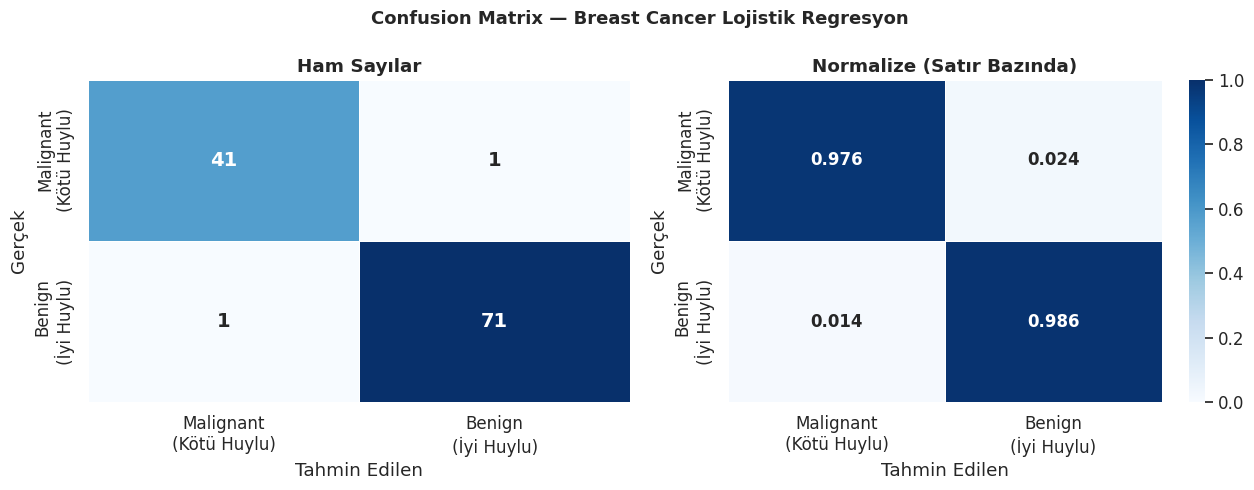

TP=71  TN=41  FP=1  FN=1
Precision (Benign) : 0.9861
Recall    (Benign) : 0.9861
F1 Score  (Benign) : 0.9861

 Tıbbi bağlamda: FN (kaçırılan kanser) daha tehlikeli → Recall kritik!


In [23]:
# ─── Confusion Matrix — Seaborn Isı Haritası ─────────────────────────────────

cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
labels = ['Malignant\n(Kötü Huylu)', 'Benign\n(İyi Huylu)']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrix — Breast Cancer Lojistik Regresyon',
             fontsize=13, fontweight='bold')

# Sol: Ham sayılar
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, ax=axes[0], cbar=False,
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Ham Sayılar', fontweight='bold')
axes[0].set_xlabel('Tahmin Edilen')
axes[0].set_ylabel('Gerçek')

# Sağ: Normalize
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, ax=axes[1], vmin=0, vmax=1,
            annot_kws={'size': 12, 'weight': 'bold'})
axes[1].set_title('Normalize (Satır Bazında)', fontweight='bold')
axes[1].set_xlabel('Tahmin Edilen')
axes[1].set_ylabel('Gerçek')

plt.tight_layout()
plt.show()

# Temel metrikleri elle hesapla
TN, FP, FN, TP = cm.ravel()
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
f1        = 2 * precision * recall / (precision + recall)

print(f'TP={TP}  TN={TN}  FP={FP}  FN={FN}')
print(f'Precision (Benign) : {precision:.4f}')
print(f'Recall    (Benign) : {recall:.4f}')
print(f'F1 Score  (Benign) : {f1:.4f}')
print(f'\n Tıbbi bağlamda: FN (kaçırılan kanser) daha tehlikeli → Recall kritik!')

## Görsel: Confusion Matrix — Meme Kanseri Lojistik Regresyon

### Confusion Matrix Nedir?

Model her hasta için "kötü huylu mu, iyi huylu mu?" diye karar veriyor. Bu matris, modelin **4 farklı karar tipini** sayıyor: doğru doğrular, yanlış doğrular, doğru yanlışlar, yanlış yanlışlar.

### Sol Grafik — Ham Sayılar (114 hasta toplamda)

Matrisi bir tablo gibi okuyun:

|  | Model: Kötü Huylu dedi | Model: İyi Huylu dedi |
|---|---|---|
| **Gerçek: Kötü Huylu** | ✅ **41** (doğru yakaladı) | ❌ **1** (gözden kaçırdı!) |
| **Gerçek: İyi Huylu** | ❌ **1** (gereksiz alarm) | ✅ **71** (doğru temiz dedi) |

Dört kutunun özel isimleri var:

- **41 → True Negative (TN):** Hasta gerçekten hastayken model hasta dedi ✅
- **71 → True Positive (TP):** Hasta gerçekten sağlıklıyken model sağlıklı dedi ✅
- **1 → False Negative (FN):** Hasta hastayken model "sağlıklı" dedi ❌ ← **EN TEHLİKELİSİ**
- **1 → False Positive (FP):** Sağlıklı hastayken model "hasta" dedi ❌ ← gereksiz endişe

---

### ağ Grafik — Normalize (Yüzdelik)

Aynı bilgiyi oransal olarak gösteriyor:

- Kötü huylu hastaların **%97.6'sı** doğru yakalanmış → sadece **%2.4'ü** kaçırılmış
- İyi huylu hastaların **%98.6'sı** doğru temiz bulunmuş → sadece **%1.4'üne** yanlış alarm verilmiş

---

### Performans Metrikleri

Altta üç önemli skor görünüyor, hepsi **0.9861:**

| Metrik | Ne Anlama Geliyor? |
|---|---|
| **Precision** | "Hasta dediklerimin ne kadarı gerçekten hasta?" → %98.6 |
| **Recall** | "Gerçek hastaların ne kadarını yakaladım?" → %98.6 |
| **F1 Score** | İkisinin dengeli ortalaması → %98.6 |

---

### Tıbbi Açıdan En Kritik Nokta

> **FN = 1** → Kanser olan 1 hasta "temiz" diye gönderilmiş.

Bu, istatistiksel olarak küçük bir hata gibi görünse de tıpta **hayati önem** taşıyor. Çünkü:

- **FP (yanlış alarm):** Sağlıklı kişiye gereksiz tetkik yapılır → can sıkıcı ama telafi edilebilir
- **FN (kaçırılan kanser):** Hasta tedavi edilmeden gönderilir → **geri dönüşü olmayabilir**

Bu yüzden tıbbi modellerde **Recall** skoru en kritik metriktir — "hiçbir hastayı kaçırma" prensibi her şeyin önüne geçer.

---
## 14. ROC Eğrisi ve AUC

**ROC (Receiver Operating Characteristic)** eğrisi, farklı karar eşiklerinde modelin False Positive Rate (FPR) vs True Positive Rate (TPR) dengesini gösterir.

$$\text{AUC} = \int_0^1 \text{TPR}(\text{FPR}) \, d(\text{FPR})$$

- AUC = 1.0 → Mükemmel model
- AUC = 0.5 → Rastgele model (çapraz köşegen)
- AUC < 0.5 → Modeli ters çevir!

In [24]:
# ─── ROC Eğrisi — Plotly ile İnteraktif ──────────────────────────────────────

# FPR, TPR ve eşik değerlerini hesapla
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba1)
auc_score = roc_auc_score(y_test, y_pred_proba1)

fig = go.Figure()

# ROC eğrisi
fig.add_trace(go.Scatter(
    x=fpr, y=tpr,
    mode='lines',
    line=dict(color='#2196F3', width=3),
    name=f'Lojistik Reg. (AUC = {auc_score:.4f})',
    customdata=thresholds,
    hovertemplate='FPR: %{x:.3f}<br>TPR: %{y:.3f}<br>Eşik: %{customdata:.3f}'
))

# Rastgele model referans çizgisi (çapraz)
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    line=dict(color='gray', width=1.5, dash='dash'),
    name='Rastgele Model (AUC = 0.50)'
))

# Optimal eşik noktası (Youden's J = TPR - FPR maksimum)
j_scores = tpr - fpr
opt_idx  = np.argmax(j_scores)
fig.add_trace(go.Scatter(
    x=[fpr[opt_idx]], y=[tpr[opt_idx]],
    mode='markers+text',
    marker=dict(size=12, color='red', symbol='star'),
    text=[f'Optimal Eşik = {thresholds[opt_idx]:.2f}'],
    textposition='top right',
    name='Optimal Eşik'
))

fig.update_layout(
    title='ROC Eğrisi — Breast Cancer Lojistik Regresyon',
    xaxis_title='False Positive Rate (FPR = 1 - Specificity)',
    yaxis_title='True Positive Rate (TPR = Recall)',
    height=450,
    template='plotly_white',
    legend=dict(x=0.55, y=0.1)
)

fig.show()

print(f'AUC Skoru     : {auc_score:.4f}')
print(f'Optimal Eşik  : {thresholds[opt_idx]:.4f}')
print(f'Bu eşikte: TPR = {tpr[opt_idx]:.4f}, FPR = {fpr[opt_idx]:.4f}')

AUC Skoru     : 0.9954
Optimal Eşik  : 0.3659
Bu eşikte: TPR = 1.0000, FPR = 0.0238


## Görsel: ROC Eğrisi — Meme Kanseri Lojistik Regresyon

### ROC Eğrisi Nedir?

Model her hasta için "hasta" olasılığı üretir. Ama bir noktada **"kaç olasılıktan itibaren hasta diyelim?"** kararı vermek gerekir. İşte ROC eğrisi, bu eşik değerini farklı noktalarda deneyerek modelin genel performansını ölçer.

### Eksenler Ne Anlama Geliyor?

| Eksen | Açıklama | İdeal |
|---|---|---|
| **Dikey (TPR / Recall)** | Gerçek hastaların kaçını yakaladım? | 1'e yakın olsun |
| **Yatay (FPR)** | Sağlıklılara kaç yanlış alarm verdim? | 0'a yakın olsun |

Yani **sol üst köşe** = mükemmel model; hem herkesi yakalıyor hem de yanlış alarm vermiyor.

---

### Mavi Eğri — Lojistik Regresyon Modelimiz

- Eğri neredeyse **direk sol üst köşeye** fırlıyor
- Yani çok az yanlış alarmla (FPR ≈ 0.02) neredeyse tüm hastaları yakalıyor (TPR = 1.0)
- Bu **olağanüstü bir performans**

### Kesikli Çizgi — Rastgele Model (AUC = 0.50)

- Tamamen şans eseri karar veren bir modeli temsil eder
- Köşegenden giden düz çizgi = para atıp karar vermekten farklı değil
- Bizim modelimiz bunun **çok çok üzerinde**

---

### Optimal Eşik = 0.37

Normalde modeller **0.50** eşiği kullanır: "olasılık > 0.5 ise hasta de." Ama bu grafik **0.37'nin** daha iyi olduğunu söylüyor.

Neden? Çünkü eşiği düşürünce:
- Model daha erken "hasta" demeye başlar
- Daha az hasta kaçırılır (FN azalır)
- Biraz daha fazla yanlış alarm verilir ama bu kabul edilebilir

> Tıbbi bağlamda "kaçırmamak" her şeyden önemli — bu yüzden eşik 0.50'den 0.37'ye çekilmiş.

Bu eşikte:
- **TPR = 1.00** → Hiçbir kanser vakası kaçırılmıyor ✅
- **FPR = 0.024** → Sağlıklıların yalnızca %2.4'üne yanlış alarm veriliyor ✅

---

### AUC Skoru: 0.9954

AUC, eğrinin altındaki alan demek. 0 ile 1 arasında:

| AUC Değeri | Anlam |
|---|---|
| 0.50 | Rastgele tahmin (işe yaramaz) |
| 0.70–0.80 | Kabul edilebilir |
| 0.80–0.90 | İyi |
| 0.90–1.00 | Mükemmel |
| **0.9954** | **Neredeyse kusursuz** |

---

### Özet

Bu model meme kanseri tespitinde **neredeyse mükemmel** bir performans sergilemiş. Eşiği 0.37'ye ayarlayarak hiçbir kanser vakasını kaçırmadan, çok az yanlış alarm veren bir sistem elde edilmiş. Tıbbi açıdan bu tam istenen senaryo.

In [25]:
# ─── Precision-Recall Eğrisi ─────────────────────────────────────────────────
# Dengesiz veri setlerinde ROC'dan daha bilgilendirici olabilir

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_pred_proba1)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=recall_curve, y=precision_curve,
    mode='lines',
    line=dict(color='#FF9800', width=3),
    name='Precision-Recall Eğrisi'
))

# Mevcut karar eşiği (0.5) noktasını göster
current_precision = precision_score = precision_curve[np.argmin(np.abs(pr_thresholds - 0.5))] if len(pr_thresholds) > 0 else None
current_recall    = recall_curve[np.argmin(np.abs(pr_thresholds - 0.5))] if len(pr_thresholds) > 0 else None

fig.update_layout(
    title='Precision-Recall Eğrisi',
    xaxis_title='Recall (Duyarlılık)',
    yaxis_title='Precision (Kesinlik)',
    height=400, template='plotly_white'
)

fig.show()
print('Dengesiz veri setlerinde PR-AUC, ROC-AUC\'den daha anlamlı olabilir.')

Dengesiz veri setlerinde PR-AUC, ROC-AUC'den daha anlamlı olabilir.


## Görsel: Precision-Recall Eğrisi

Temel Kavramlar

Bu eğri, modelin iki hedef arasındaki dengeyi gösteriyor:

| Kavram | Soru | İdeal |
|---|---|---|
| **Precision (Kesinlik)** | "Hasta dediklerimin kaçı gerçekten hasta?" | 1'e yakın |
| **Recall (Duyarlılık)** | "Gerçek hastaların kaçını yakaladım?" | 1'e yakın |

Problem şu: **ikisini aynı anda maksimuma çıkarmak çok zordur.** Birini artırmaya çalışınca diğeri genellikle düşer.

---

### Bu Eğri Ne Anlatıyor?

Eğri neredeyse **sol üst köşede sabit** kalıyor — bu son derece iyi bir işaret.

- **Recall 0 → 0.8 arasında:** Precision **%100** sabit → Model "hasta" dediğinde **hiç yanılmıyor**, üstelik hastaların büyük çoğunluğunu da yakalıyor
- **Recall 0.8 → 1.0 arasında:** Precision hafif düşüyor (~%96'ya) → Model son hastaları da yakalamaya çalışırken birkaç yanlış alarm veriyor

---

### ROC Eğrisinden Farkı Ne?

Bir önceki görselde ROC eğrisini görmüştük. İkisi farklı şeyleri ölçer:

| | ROC Eğrisi | PR Eğrisi |
|---|---|---|
| **Odak** | Genel denge | Azınlık sınıf performansı |
| **Ne zaman kullanılır?** | Dengeli veri setleri | **Dengesiz veri setleri** |

> Alttaki not tam bunu söylüyor: Kanser verisinde hasta sayısı sağlıklıya göre az olduğunda, **PR eğrisi daha gerçekçi bir tablo** çizer.

---

### Özet

Bu eğri modelimizin **hem hassas hem de kapsayıcı** olduğunu gösteriyor. Hastaları kaçırmadan, yanlış alarm da vermeden çalışıyor — tıbbi bir model için mümkün olan en iyi senaryo.

---
## 15. Katsayı Yorumlama — Odds Ratio

Lojistik regresyonun en güçlü yanlarından biri **yorumlanabilirliği**dir.

### Log-Odds (Logit):

$$\log\left(\frac{P(y=1)}{P(y=0)}\right) = \mathbf{w}^T \mathbf{x} + b$$

### Odds Ratio:

$$\text{Odds Ratio}_j = e^{w_j}$$

**Yorumlama:**
- $e^{w_j} > 1$ → Özellik $j$ arttıkça y=1 olasılığı artar
- $e^{w_j} < 1$ → Özellik $j$ arttıkça y=1 olasılığı azalır  
- $e^{w_j} = 2.0$ → Özellik $j$ 1 birim artınca odds **2 katına** çıkar

In [26]:
# ─── Katsayılar ve Odds Ratio Görselleştirmesi ───────────────────────────────

# Katsayıları ve odds ratio'yu hesapla
coefs      = lr_model.coef_[0]          # w değerleri
odds_ratio = np.exp(coefs)              # e^w

# DataFrame oluştur
df_coef = pd.DataFrame({
    'Özellik'    : cancer.feature_names,
    'Katsayı (w)': coefs,
    'Odds Ratio' : odds_ratio
}).sort_values('Katsayı (w)', ascending=False)

# Top 15 özelliği göster
top15 = df_coef.head(15)
bot5  = df_coef.tail(5)

# Plotly: Yatay bar grafik
fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_coef['Katsayı (w)'],
    y=df_coef['Özellik'],
    orientation='h',
    marker=dict(
        color=df_coef['Katsayı (w)'].apply(
            lambda v: '#2ECC71' if v > 0 else '#E74C3C'
        )
    ),
    text=df_coef['Katsayı (w)'].round(3),
    textposition='outside',
    customdata=df_coef['Odds Ratio'].round(3),
    hovertemplate='%{y}<br>w = %{x:.3f}<br>Odds Ratio = %{customdata:.3f}'
))

fig.update_layout(
    title='Lojistik Regresyon Katsayıları (w)',
    xaxis_title='Katsayı Değeri',
    height=700,
    template='plotly_white'
)

fig.add_vline(x=0, line_dash='dash', line_color='black', line_width=1)
fig.show()

print('Yeşil (pozitif): Bu özellik arttıkça y=1 (Benign) olasılığı ARTAR')
print('Kırmızı (negatif): Bu özellik arttıkça y=1 (Benign) olasılığı AZALIR')
print()
print('Top 5 pozitif etkili özellik:')
print(top15[['Özellik', 'Katsayı (w)', 'Odds Ratio']].head(5).to_string(index=False))

Yeşil (pozitif): Bu özellik arttıkça y=1 (Benign) olasılığı ARTAR
Kırmızı (negatif): Bu özellik arttıkça y=1 (Benign) olasılığı AZALIR

Top 5 pozitif etkili özellik:
                Özellik  Katsayı (w)  Odds Ratio
       mean compactness     0.648342    1.912367
      compactness error     0.647227    1.910236
fractal dimension error     0.437894    1.549441
         symmetry error     0.360492    1.434034
          texture error     0.248823    1.282515


---
## 16. Regularization: L1 (Lasso) ve L2 (Ridge)

Regularization, overfitting'i önlemek için maliyet fonksiyonuna bir **ceza terimi** ekler:

### L2 Regularization (Ridge):
$$\mathcal{L}_{ridge} = \mathcal{L}_{CE} + \frac{\lambda}{2} \|\mathbf{w}\|_2^2 = \mathcal{L}_{CE} + \frac{\lambda}{2} \sum_j w_j^2$$

→ Ağırlıkları küçültür ama tam sıfır yapmaz

### L1 Regularization (Lasso):
$$\mathcal{L}_{lasso} = \mathcal{L}_{CE} + \lambda \|\mathbf{w}\|_1 = \mathcal{L}_{CE} + \lambda \sum_j |w_j|$$

→ Bazı ağırlıkları **tam sıfır** yapar → otomatik özellik seçimi

### Sklearn'de C parametresi:

$$C = \frac{1}{\lambda} \quad \Rightarrow \quad \text{C küçük} = \text{güçlü regularization}$$

In [27]:
# ─── L1 ve L2 Regularization Karşılaştırması ─────────────────────────────────
# Farklı C değerlerinde performans ve katsayı büyüklükleri

C_values    = [0.001, 0.01, 0.1, 1.0, 10, 100, 1000]
results_l1  = []
results_l2  = []

for C_val in C_values:
    # ── L2 modeli ────────────────────────────────────────────────────────────
    lr_l2 = LogisticRegression(C=C_val, penalty='l2', solver='lbfgs',
                                max_iter=2000, random_state=RANDOM_STATE)
    lr_l2.fit(X_train_sc, y_train)
    acc_l2 = lr_l2.score(X_test_sc, y_test)
    w_norm_l2 = np.linalg.norm(lr_l2.coef_)  # ağırlık normu
    zero_l2   = (np.abs(lr_l2.coef_[0]) < 0.01).sum()  # yaklaşık sıfır sayısı
    results_l2.append({'C': C_val, 'Acc': acc_l2,
                        'W Normu': w_norm_l2, 'Sıfır≈': zero_l2})

    # ── L1 modeli (liblinear solver L1 destekler) ─────────────────────────────
    lr_l1 = LogisticRegression(C=C_val, penalty='l1', solver='liblinear',
                                max_iter=2000, random_state=RANDOM_STATE)
    lr_l1.fit(X_train_sc, y_train)
    acc_l1 = lr_l1.score(X_test_sc, y_test)
    w_norm_l1 = np.linalg.norm(lr_l1.coef_)
    zero_l1   = (lr_l1.coef_[0] == 0).sum()  # tam sıfır sayısı
    results_l1.append({'C': C_val, 'Acc': acc_l1,
                        'W Normu': w_norm_l1, 'Sıfır=0': zero_l1})

df_l1 = pd.DataFrame(results_l1)
df_l2 = pd.DataFrame(results_l2)

# Görselleştir
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Test Doğruluğu vs C', 'Ağırlık Normu vs C'))

for df_reg, name, color in [(df_l2, 'L2 (Ridge)', '#2196F3'),
                              (df_l1, 'L1 (Lasso)', '#FF9800')]:
    fig.add_trace(go.Scatter(
        x=df_reg['C'], y=df_reg['Acc'],
        mode='lines+markers', line=dict(color=color, width=2.5),
        name=name
    ), row=1, col=1)
    fig.add_trace(go.Scatter(
        x=df_reg['C'], y=df_reg['W Normu'],
        mode='lines+markers', line=dict(color=color, width=2.5),
        name=name, showlegend=False
    ), row=1, col=2)

fig.update_xaxes(type='log', title_text='C (log ölçek)')
fig.update_yaxes(title_text='Test Doğruluğu', row=1, col=1)
fig.update_yaxes(title_text='Ağırlık L2 Normu', row=1, col=2)
fig.update_layout(height=420, title='L1 vs L2 Regularization',
                   template='plotly_white')
fig.show()

print('L1 (Lasso) sıfır olan ağırlık sayısı (özellik seçimi):')
for r in results_l1:
    print(f'  C={r["C"]:6.3f} → {int(r["Sıfır=0"])}/30 özellik sıfırlandı')

L1 (Lasso) sıfır olan ağırlık sayısı (özellik seçimi):
  C= 0.001 → 30/30 özellik sıfırlandı
  C= 0.010 → 27/30 özellik sıfırlandı
  C= 0.100 → 22/30 özellik sıfırlandı
  C= 1.000 → 14/30 özellik sıfırlandı
  C=10.000 → 7/30 özellik sıfırlandı
  C=100.000 → 5/30 özellik sıfırlandı
  C=1000.000 → 1/30 özellik sıfırlandı


---
## 17. Çok Sınıflı Lojistik Regresyon

Lojistik regresyon doğal olarak ikili sınıflandırma yapar. Çok sınıf için iki strateji vardır:

### One-vs-Rest (OvR):
K sınıf için K ayrı ikili sınıflandırıcı eğitilir. Her biri "sınıf k vs diğerleri" sorusunu yanıtlar.

### Multinomial (Softmax):
Tek bir model, tüm sınıfları birlikte modeller. Softmax fonksiyonu kullanılır:

$$P(y=k \mid \mathbf{x}) = \frac{e^{\mathbf{w}_k^T \mathbf{x} + b_k}}{\sum_{j=1}^{K} e^{\mathbf{w}_j^T \mathbf{x} + b_j}}$$

Tüm olasılıklar toplamı 1'dir.

In [28]:
# ─── Iris Veri Seti ile Çok Sınıflı Lojistik Regresyon ───────────────────────

iris = load_iris()
X_iris, y_iris = iris.data, iris.target

X_ir_train, X_ir_test, y_ir_train, y_ir_test = train_test_split(
    X_iris, y_iris, test_size=0.25, random_state=RANDOM_STATE, stratify=y_iris
)

scaler_iris = StandardScaler()
X_ir_tr_sc = scaler_iris.fit_transform(X_ir_train)
X_ir_te_sc = scaler_iris.transform(X_ir_test)

# One-vs-Rest (OvR)
lr_ovr = LogisticRegression(multi_class='ovr', solver='lbfgs',
                              max_iter=1000, random_state=RANDOM_STATE)
lr_ovr.fit(X_ir_tr_sc, y_ir_train)

# Multinomial (Softmax)
lr_multi = LogisticRegression(multi_class='multinomial', solver='lbfgs',
                               max_iter=1000, random_state=RANDOM_STATE)
lr_multi.fit(X_ir_tr_sc, y_ir_train)

acc_ovr   = lr_ovr.score(X_ir_te_sc, y_ir_test)
acc_multi = lr_multi.score(X_ir_te_sc, y_ir_test)

print('=== Çok Sınıflı Lojistik Regresyon — Iris (3 Sınıf) ===')
print(f'OvR (One-vs-Rest)   : {acc_ovr:.4f} ({acc_ovr*100:.1f}%)')
print(f'Multinomial (Softmax): {acc_multi:.4f} ({acc_multi*100:.1f}%)')
print()
print('OvR Katsayı matrisi boyutu:',  lr_ovr.coef_.shape, '  (K x d = 3 x 4)')
print('Multi Katsayı matrisi boyutu:', lr_multi.coef_.shape)

=== Çok Sınıflı Lojistik Regresyon — Iris (3 Sınıf) ===
OvR (One-vs-Rest)   : 0.8158 (81.6%)
Multinomial (Softmax): 0.9211 (92.1%)

OvR Katsayı matrisi boyutu: (3, 4)   (K x d = 3 x 4)
Multi Katsayı matrisi boyutu: (3, 4)


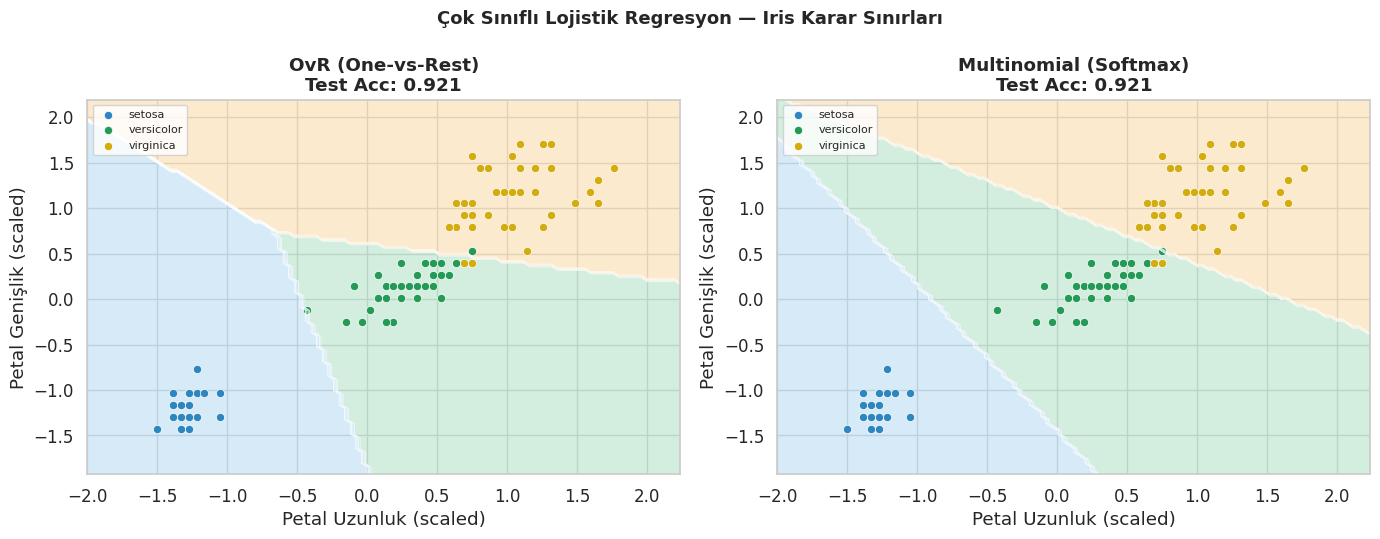

In [29]:
# ─── Çok Sınıflı Karar Sınırları (Petal özellikleri) ────────────────────────

import matplotlib.colors as mcolors

# Sadece 2 özellik kullan (görselleştirme için)
X_2feat = X_iris[:, 2:]   # petal length, petal width

X_2f_tr, X_2f_te, y_2f_tr, y_2f_te = train_test_split(
    X_2feat, y_iris, test_size=0.25, random_state=RANDOM_STATE, stratify=y_iris
)

sc2 = StandardScaler()
X_2f_tr_sc = sc2.fit_transform(X_2f_tr)
X_2f_te_sc = sc2.transform(X_2f_te)

# Grid
h = 0.04
x0_min, x0_max = X_2f_tr_sc[:, 0].min()-0.5, X_2f_tr_sc[:, 0].max()+0.5
x1_min, x1_max = X_2f_tr_sc[:, 1].min()-0.5, X_2f_tr_sc[:, 1].max()+0.5
xx2, yy2 = np.meshgrid(np.arange(x0_min, x0_max, h),
                        np.arange(x1_min, x1_max, h))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
strategies = [('ovr', 'OvR (One-vs-Rest)'), ('multinomial', 'Multinomial (Softmax)')]
cmap_light = mcolors.ListedColormap(['#AED6F1', '#A9DFBF', '#FAD7A0'])
colors3    = ['#2E86C1', '#239B56', '#D4AC0D']

for ax, (strategy, title) in zip(axes, strategies):
    lr_plot = LogisticRegression(multi_class=strategy, solver='lbfgs',
                                  max_iter=1000, random_state=RANDOM_STATE)
    lr_plot.fit(X_2f_tr_sc, y_2f_tr)
    Z = lr_plot.predict(np.c_[xx2.ravel(), yy2.ravel()]).reshape(xx2.shape)
    ax.contourf(xx2, yy2, Z, alpha=0.5, cmap=cmap_light)
    ax.contour(xx2, yy2, Z, colors='white', linewidths=0.5)
    for cls, c in enumerate(colors3):
        mask = y_2f_tr == cls
        ax.scatter(X_2f_tr_sc[mask, 0], X_2f_tr_sc[mask, 1],
                   c=c, s=35, edgecolors='white', linewidth=0.5,
                   label=iris.target_names[cls])
    acc_p = lr_plot.score(X_2f_te_sc, y_2f_te)
    ax.set_title(f'{title}\nTest Acc: {acc_p:.3f}', fontweight='bold')
    ax.set_xlabel('Petal Uzunluk (scaled)')
    ax.set_ylabel('Petal Genişlik (scaled)')
    ax.legend(loc='upper left', fontsize=8)

plt.suptitle('Çok Sınıflı Lojistik Regresyon — Iris Karar Sınırları',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Görsel: Çok Sınıflı Lojistik Regresyon — Iris Karar Sınırları

Bu sefer model **2 değil 3 çiçek türünü** (setosa 🔵, versicolor 🟢, virginica 🟡) birbirinden ayırt etmeye çalışıyor.

Her iki grafik de aynı işi **farklı yöntemlerle** yapıyor:

- **Sol (OvR):** "Bu setosa mı, değil mi?" diye 3 ayrı ikili karar veriyor, sonra birleştiriyor
- **Sağ (Multinomial):** 3 sınıfı **aynı anda** birlikte değerlendiriyor

İkisi de **%92.1 doğruluk** elde etmiş — sonuç aynı, yol farklı.

### Dikkat Çeken Nokta
- 🔵 Setosa tamamen ayrışmış, model hiç şaşırmıyor
- 🟢 Versicolor ile 🟡 Virginica ortada iç içe geçiyor → model burada zorlanıyor, sınırlar kayıyor

---
## 18. KNN ile Karşılaştırma

| Özellik | Lojistik Regresyon | KNN |
|---------|-------------------|-----|
| Karar sınırı | **Doğrusal** | Doğrusal olmayan |
| Eğitim hızı | Orta (iter.) | **Anında (O(1))** |
| Tahmin hızı | **Hızlı (O(d))** | Yavaş (O(Nd)) |
| Yorumlanabilirlik | **Yüksek** (katsayılar) | Düşük |
| Olasılık kalitesi | **İyi (kalibre)** | Yaklaşık |
| Ölçeklendirme | Gerekli | Zorunlu |
| Bellek | **Az** | Yüksek (tüm veri) |
| Regularization | **Yerleşik (L1/L2)** | Yok |

In [30]:
# ─── KNN vs Lojistik Regresyon — CV ile Karşılaştırma ────────────────────────

# 5-katlı stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'Lojistik Reg (L2, C=1)' : LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE),
    'Lojistik Reg (L1, C=1)' : LogisticRegression(C=1.0, penalty='l1', solver='liblinear', random_state=RANDOM_STATE),
    'Lojistik Reg (L2, C=0.1)': LogisticRegression(C=0.1, max_iter=1000, random_state=RANDOM_STATE),
    'KNN (K=5)'               : KNeighborsClassifier(n_neighbors=5),
    'KNN (K=11)'              : KNeighborsClassifier(n_neighbors=11),
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_sc, y_train,
                              cv=cv, scoring='f1', n_jobs=-1)
    cv_results[name] = scores

# Altair ile görselleştir
records = []
for model_name, scores in cv_results.items():
    for fold_i, score in enumerate(scores):
        records.append({'Model': model_name, 'F1': score, 'Fold': f'Fold {fold_i+1}'})

df_cv = pd.DataFrame(records)

chart = alt.Chart(df_cv).mark_boxplot(extent='min-max').encode(
    x=alt.X('F1:Q', scale=alt.Scale(domain=[0.9, 1.01]), title='F1 Skoru (5-Fold CV)'),
    y=alt.Y('Model:N', sort='-x'),
    color=alt.Color('Model:N', legend=None)
).properties(
    width=500, height=220,
    title='KNN vs Lojistik Regresyon — 5-Fold CV F1 Skoru'
)

chart.configure_title(fontSize=13).show()

print('\nModel Karşılaştırması (CV F1 Ortalama ± Std):')
for name, scores in cv_results.items():
    print(f'  {name:35s}: {scores.mean():.4f} ± {scores.std():.4f}')

alt.Chart(...)


Model Karşılaştırması (CV F1 Ortalama ± Std):
  Lojistik Reg (L2, C=1)             : 0.9825 ± 0.0078
  Lojistik Reg (L1, C=1)             : 0.9755 ± 0.0102
  Lojistik Reg (L2, C=0.1)           : 0.9861 ± 0.0042
  KNN (K=5)                          : 0.9688 ± 0.0090
  KNN (K=11)                         : 0.9692 ± 0.0137


---
## 19. Gerçek Dünya Uygulaması: Titanic Hayatta Kalma Tahmini

**Kaynak:** Kaggle — https://www.kaggle.com/c/titanic  
**Görev:** Yolcunun hayatta kalıp kalmadığını tahmin et (Survived: 0/1)

Bu bölümde:
1. Ham veriden feature engineering
2. Kategorik değişken kodlama
3. Pipeline ile temiz akış
4. Model yorumlama

In [31]:
# ─── Titanic Verisi — Seaborn'un Yerleşik Veri Seti ─────────────────────────
# Seaborn kütüphanesi hazır Titanic verisini içerir

titanic_raw = sns.load_dataset('titanic')

print(f'Veri boyutu: {titanic_raw.shape}')
print(f'Sütunlar: {list(titanic_raw.columns)}')
print(f'Eksik değerler:\n{titanic_raw.isnull().sum()[titanic_raw.isnull().sum()>0]}')
titanic_raw.head()

Veri boyutu: (891, 15)
Sütunlar: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
Eksik değerler:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


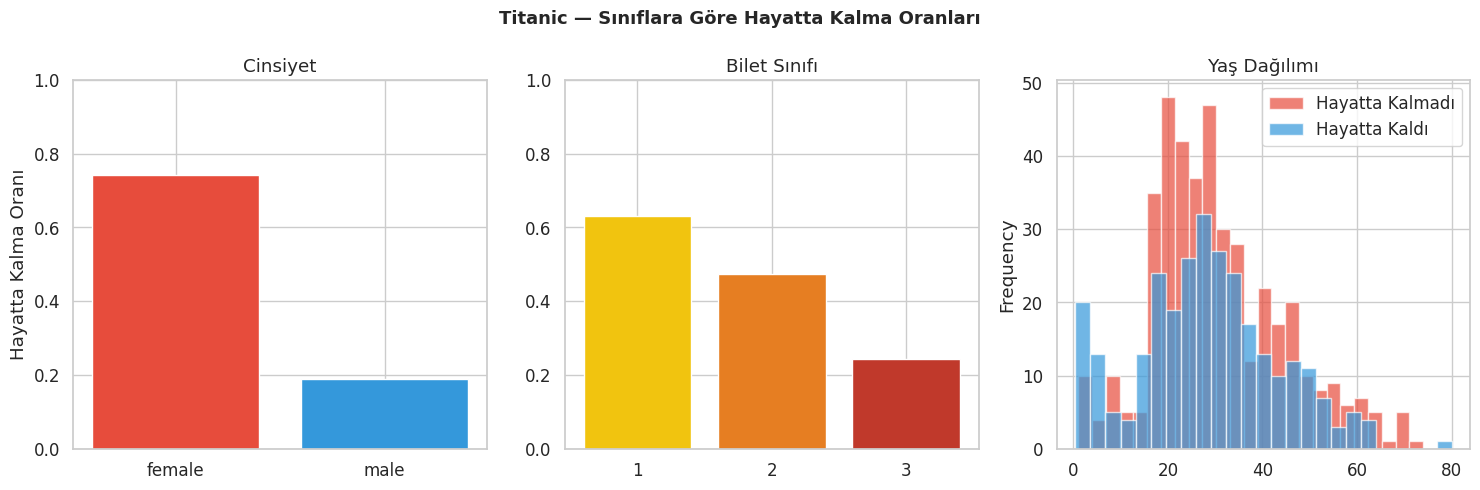

In [33]:
# ─── Titanic EDA: Hayatta Kalma Oranları ─────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Titanic — Sınıflara Göre Hayatta Kalma Oranları', fontsize=13, fontweight='bold')

# Cinsiyet
surv_sex = titanic_raw.groupby('sex')['survived'].mean().reset_index()
axes[0].bar(surv_sex['sex'], surv_sex['survived'], color=['#E74C3C', '#3498DB'])
axes[0].set_title('Cinsiyet')
axes[0].set_ylabel('Hayatta Kalma Oranı')
axes[0].set_ylim(0, 1)

# Sınıf
surv_cls = titanic_raw.groupby('pclass')['survived'].mean().reset_index()
axes[1].bar(surv_cls['pclass'].astype(str), surv_cls['survived'],
            color=['#F1C40F', '#E67E22', '#C0392B'])
axes[1].set_title('Bilet Sınıfı')
axes[1].set_ylim(0, 1)

colors = ['#E74C3C', '#3498DB']
labels = ['Hayatta Kalmadı', 'Hayatta Kaldı']

for (survived, group), color, label in zip(
        titanic_raw.groupby('survived')['age'], colors, labels):
    group.plot(kind='hist', ax=axes[2],
               alpha=0.7, bins=25,
               color=color, label=label)

axes[2].set_title('Yaş Dağılımı')
axes[2].legend()

plt.tight_layout()
plt.show()

In [34]:
# ─── Feature Engineering — Titanic ──────────────────────────────────────────

df_titanic = titanic_raw.copy()

# 1. Eksik yaşları medyan ile doldur
df_titanic['age'].fillna(df_titanic['age'].median(), inplace=True)

# 2. Eksik embarked değerlerini mod ile doldur
df_titanic['embarked'].fillna(df_titanic['embarked'].mode()[0], inplace=True)

# 3. Cinsiyet: male=1, female=0
df_titanic['sex_enc'] = (df_titanic['sex'] == 'male').astype(int)

# 4. Embarked: One-Hot Encoding
embarked_dummies = pd.get_dummies(df_titanic['embarked'], prefix='emb', drop_first=True)
df_titanic = pd.concat([df_titanic, embarked_dummies], axis=1)

# 5. Yeni özellik: aile boyutu
df_titanic['family_size'] = df_titanic['sibsp'] + df_titanic['parch'] + 1

# 6. Yeni özellik: yalnız mı?
df_titanic['is_alone'] = (df_titanic['family_size'] == 1).astype(int)

# Kullanılacak özellikler
FEATURES = ['pclass', 'sex_enc', 'age', 'sibsp', 'parch',
            'fare', 'family_size', 'is_alone', 'emb_Q', 'emb_S']

X_titanic = df_titanic[FEATURES].values
y_titanic = df_titanic['survived'].values

print(f'Özellik matrisi: {X_titanic.shape}')
print(f'Hayatta kalma oranı: {y_titanic.mean():.2%}')

Özellik matrisi: (891, 10)
Hayatta kalma oranı: 38.38%


In [35]:
# ─── Pipeline ile Titanic Modeli ─────────────────────────────────────────────
# Pipeline: Veri sızıntısını önler, kodu temizler

X_t_train, X_t_test, y_t_train, y_t_test = train_test_split(
    X_titanic, y_titanic,
    test_size=0.20, random_state=RANDOM_STATE, stratify=y_titanic
)

# Pipeline oluştur: Ölçeklendirme + Lojistik Regresyon
pipeline_titanic = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(C=0.5, penalty='l2',
                               max_iter=1000, random_state=RANDOM_STATE))
])

pipeline_titanic.fit(X_t_train, y_t_train)

y_t_pred = pipeline_titanic.predict(X_t_test)
acc_t    = accuracy_score(y_t_test, y_t_pred)
f1_t     = f1_score(y_t_test, y_t_pred)

print('=== Titanic Hayatta Kalma Tahmini ===')
print(f'Test Doğruluğu : {acc_t:.4f} ({acc_t*100:.1f}%)')
print(f'F1 Skoru       : {f1_t:.4f}')
print()
print(classification_report(y_t_test, y_t_pred,
                              target_names=['Hayatta Kalmadı', 'Hayatta Kaldı']))

=== Titanic Hayatta Kalma Tahmini ===
Test Doğruluğu : 0.8045 (80.4%)
F1 Skoru       : 0.7287

                 precision    recall  f1-score   support

Hayatta Kalmadı       0.82      0.88      0.85       110
  Hayatta Kaldı       0.78      0.68      0.73        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



In [36]:
# ─── Katsayı Yorumlama — Titanic ────────────────────────────────────────────

lr_t = pipeline_titanic.named_steps['lr']
coefs_t = lr_t.coef_[0]
odds_t  = np.exp(coefs_t)

df_coef_t = pd.DataFrame({
    'Özellik'   : FEATURES,
    'Katsayı'   : coefs_t,
    'Odds Ratio': odds_t
}).sort_values('Katsayı', ascending=False)

# Plotly görselleştirme
fig = go.Figure(go.Bar(
    x=df_coef_t['Katsayı'],
    y=df_coef_t['Özellik'],
    orientation='h',
    text=df_coef_t['Odds Ratio'].round(2),
    texttemplate='OR=%{text}',
    textposition='outside',
    marker_color=df_coef_t['Katsayı'].apply(
        lambda v: '#3498DB' if v > 0 else '#E74C3C'
    ),
    customdata=df_coef_t['Odds Ratio'].round(3),
    hovertemplate='%{y}<br>w=%{x:.3f}<br>OR=%{customdata:.3f}'
))

fig.update_layout(
    title='Titanic — Lojistik Regresyon Katsayıları & Odds Ratio',
    xaxis_title='Katsayı',
    height=380, template='plotly_white'
)
fig.add_vline(x=0, line_dash='dash', line_color='black')
fig.show()

print('Yorumlama Örnekleri:')
for _, row in df_coef_t.iterrows():
    yon = 'ARTTIRIR' if row['Katsayı'] > 0 else 'AZALTIR'
    print(f'  {row["Özellik"]:15s}: OR={row["Odds Ratio"]:.3f} → {yon} hayatta kalma olasılığını')

Yorumlama Örnekleri:
  emb_Q          : OR=1.108 → ARTTIRIR hayatta kalma olasılığını
  fare           : OR=1.096 → ARTTIRIR hayatta kalma olasılığını
  parch          : OR=0.941 → AZALTIR hayatta kalma olasılığını
  emb_S          : OR=0.869 → AZALTIR hayatta kalma olasılığını
  family_size    : OR=0.803 → AZALTIR hayatta kalma olasılığını
  sibsp          : OR=0.756 → AZALTIR hayatta kalma olasılığını
  is_alone       : OR=0.738 → AZALTIR hayatta kalma olasılığını
  age            : OR=0.622 → AZALTIR hayatta kalma olasılığını
  pclass         : OR=0.418 → AZALTIR hayatta kalma olasılığını
  sex_enc        : OR=0.296 → AZALTIR hayatta kalma olasılığını


---
## 20. Özet ve Sonraki Adımlar

### Bu Derste Öğrendiklerimiz

| Konu | Ana Çıkarım |
|------|-------------|
| Sigmoid Fonksiyonu | Herhangi bir gerçek sayıyı (0,1)'e sıkıştırır |
| Karar Sınırı | Doğrusal — $\mathbf{w}^T\mathbf{x} + b = 0$ |
| Cross-Entropy | Konveks kayıp → global minimum garantili |
| Gradyan İniş | $\mathbf{w} \leftarrow \mathbf{w} - \eta \nabla_w \mathcal{L}$ |
| Regularization | L2: ağırlıkları küçült | L1: sıfırla (özellik seçimi) |
| C parametresi | $C = 1/\lambda$ — küçük C = güçlü regularization |
| Katsayı yorumu | $e^{w_j}$ = odds ratio — değişimin çarpanı |
| Pipeline | Veri sızıntısını önler, kodu temizler |

---

### Pratik Kurallar:

1. Her zaman StandardScaler kullan (gradyan iniş ölçek duyarlı)
2. Varsayılan C=1 ile başla, CV ile optimize et
3. Yorumlanabilirlik önemliyse: odds ratio analizi yap
4. ROC-AUC ile model karşılaştır, F1 ile raporla
5. Doğrusal olmayan sınır gerekliyse → SVM, RF, XGBoost'a geç

---

### Sonraki Hafta: Karar Ağaçları + Naive Bayes

| Özellik | Lojistik Reg | Karar Ağacı | Naive Bayes |
|---------|-------------|-------------|-------------|
| Karar sınırı | Doğrusal | Doğrusal olmayan | Doğrusal |
| Yorumlama | ✅ Yüksek | ✅✅ Çok yüksek | ✅ Yüksek |
| Ölçeklendirme | Gerekli | Gerekmez | Gerekmez |
| Olasılık kalitesi | ✅ İyi | ⚠️ Zayıf | ⚠️ Orta |

---

### Ek Kaynaklar:

- **Kitap:** Bishop — PRML, Bölüm 4 (Lineer Sınıflandırma)
- **Kitap:** Géron — Hands-On ML, Bölüm 4
- **Sklearn:** https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
- **Makale:** Cox (1958) — *The Regression Analysis of Binary Sequences*

In [37]:
# ─── DERS SONU: Tüm Sonuçların Özeti ────────────────────────────────────────

print('=' * 60)
print(' LOJİSTİK REGRESYON — DERS ÖZET TABLOSU')
print('=' * 60)
print()
print('Breast Cancer (İkili Sınıflandırma):')
print(f'   Sıfırdan (GD, η=0.1, 1000 iter): {test_acc:.4f}')
print(f'   Sklearn (L2, C=1.0)            : {acc:.4f}')

for r in results_l1[-3:]:
    print(f'   L1, C={r["C"]:5.3f}                 : {r["Acc"]:.4f}')

print()
print('Iris (Çok Sınıflı):')
print(f'   OvR (One-vs-Rest)               : {acc_ovr:.4f}')
print(f'   Multinomial (Softmax)           : {acc_multi:.4f}')

print()
print('Titanic (Gerçek Dünya):')
print(f'   Pipeline (L2, C=0.5)            : {acc_t:.4f}')
print(f'   F1 Skoru                        : {f1_t:.4f}')

print()
print('=' * 60)
print(' Sonraki Ders: Karar Ağaçları + Naive Bayes')
print('=' * 60)

 LOJİSTİK REGRESYON — DERS ÖZET TABLOSU

Breast Cancer (İkili Sınıflandırma):
   Sıfırdan (GD, η=0.1, 1000 iter): 0.9737
   Sklearn (L2, C=1.0)            : 0.9825
   L1, C=10.000                 : 0.9649
   L1, C=100.000                 : 0.9298
   L1, C=1000.000                 : 0.9386

Iris (Çok Sınıflı):
   OvR (One-vs-Rest)               : 0.8158
   Multinomial (Softmax)           : 0.9211

Titanic (Gerçek Dünya):
   Pipeline (L2, C=0.5)            : 0.8045
   F1 Skoru                        : 0.7287

 Sonraki Ders: Karar Ağaçları + Naive Bayes
